# Explainable Credit Risk Prediction: XGBoost + TreeSHAP + Constrained DiCE

**MSc Dissertation (Baze University, Abuja): Explainable Artificial Intelligence in Financial Risk Prediction: A Dual-Layer Framework for Stable and Actionable Counterfactuals**

**Author:** Jamal E.O. Obaseki (BU/23C/PGS/10310)

This notebook holds all the code behind the modelling and the deployment in the dissertation. Each step has three parts:

* **What we do** (the code),
* **Why we do it** (plain English, as simple as possible),
* **What the result means** (read straight from the output under each cell).

Think of the whole project like a careful loan officer at a bank in Abuja who has three jobs:

i. **Guess** who may fail to pay back a loan (the *predictor*, XGBoost).
ii. **Show the reasons** behind every guess (the *global explainer*, TreeSHAP).
iii. **Tell a rejected person what they can realistically change** to be approved next time (the *recourse explainer*, constrained DiCE).

**How to run it:** run the cells from top to bottom. Every random step uses the seed `42`, so the numbers you see below come out the same each time with the package versions listed in Step 0. The run takes about 15 to 20 minutes on a normal laptop or on Google Colab.

| Notebook step | Dissertation section it supports |
|---|---|
| Steps 2 to 5 (data, special codes, WoE, split, SMOTE) | 3.3, 4.2 |
| Steps 6 to 10 (baselines, tuning, final model, evaluation, significance) | 3.4.2, 3.5.1, 3.6.1, 4.3 |
| Step 11 (design checks) | 4.2, 5.4 |
| Steps 12 and 13 (TreeSHAP global and local) | 3.4.1, 4.4 |
| Steps 14 to 19 (constrained DiCE and its quality) | 3.5.2, 3.6.2, 4.5 |
| Step 20 (stability, SHAP versus LIME) | 3.6.2, 4.6.3, research question iii |
| Step 21 (timings) | 4.6.2 |
| Step 22 (files for the web app) | Deployment (Appendix) |
| Step 23 (final results table) | Chapter 4 and Chapter 5 |

## Step 0: Install the exact package versions

**Why:** different versions of these libraries can give slightly different numbers. XGBoost changed its default tree-building method after version 1.7, so we pin version 1.7.6. Pinning versions is what makes the results *reproducible*: anyone can run this and get the same answer.

On Google Colab, remove the `#` in front of the `pip` line, run it once, then restart the runtime. On a local computer, use Python 3.11 and the file `requirements-notebook.txt`.

In [1]:
# !pip install -q "xgboost==1.7.6" "numpy==1.26.4" "pandas==2.2.3" "scikit-learn==1.5.2" "imbalanced-learn==0.14.2" "shap==0.49.1" "dice-ml==0.12" "optuna==5.0.0" "lime==0.2.0.1" "scipy==1.17.1" "matplotlib" "seaborn" "joblib"
import sys, importlib
print("Python", sys.version.split()[0])
for pkg in ["numpy", "pandas", "sklearn", "imblearn", "xgboost", "optuna", "shap", "dice_ml", "lime", "scipy"]:
    mod = importlib.import_module(pkg)
    print(f"{pkg:10s} {getattr(mod, '__version__', 'n/a')}")

Python 3.11.17
numpy      1.26.4


pandas     2.2.3


sklearn    1.5.2


imblearn   0.14.2
xgboost    1.7.6
optuna     5.0.0


/home/claude/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


shap       0.49.1
dice_ml    n/a
lime       n/a
scipy      1.17.1


## Step 1: Load the tools and fix the random seed

**Why:** a *random seed* is like telling a dice to always roll the same numbers in the same order. We set it to 42 everywhere, so the split of the data, the synthetic rows from SMOTE, the tuning trials and the counterfactual search all repeat exactly.

We also set one plain black and grey style for every chart, so the figures print clearly in a black and white thesis.

In [2]:
import os, json, time, random, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import optuna
from optuna.samplers import TPESampler
import shap
import dice_ml
from dice_ml import Dice
from lime import lime_tabular
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE); random.seed(RANDOM_STATE)
os.makedirs("figures", exist_ok=True)

plt.rcParams.update({
    "font.family": "serif", "font.serif": ["Times New Roman", "Liberation Serif", "DejaVu Serif"],
    "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11, "axes.edgecolor": "#333333",
    "axes.grid": True, "grid.color": "#dddddd", "grid.linewidth": 0.6, "axes.axisbelow": True,
    "savefig.dpi": 300, "savefig.bbox": "tight", "figure.dpi": 100,
})
GREY_CMAP = matplotlib.colors.LinearSegmentedColormap.from_list("greys_trunc", ["#d9d9d9", "#000000"])
TIMINGS = {}
print("Tools loaded. Seed =", RANDOM_STATE)

Tools loaded. Seed = 42


## Step 2: Load the HELOC data

**What it is:** the FICO HELOC (Home Equity Line of Credit) data. Each row is one person who asked for a credit line. There are **23 numbers** about their credit history (how long they have had accounts, how many late payments, how much of their credit limit they use, and so on) and **one answer column**, `RiskPerformance`, which says `Bad` (they fell 90 days or more behind on payments) or `Good`.

**Why it matters:** this is the same data the dissertation names in Section 3.3.1. We turn the answer into a number: `Bad = 1` (risky, would be *rejected*) and `Good = 0` (safe, would be *approved*).

In [3]:
candidates = ["heloc_dataset_v1.csv", "heloc_dataset_v1 (1).csv"]
path = next((p for p in candidates if os.path.exists(p)), None)
if path is None:                       # Google Colab: ask for the file
    from google.colab import files
    uploaded = files.upload(); path = list(uploaded.keys())[0]
df = pd.read_csv(path)
FEATURES = [c for c in df.columns if c != "RiskPerformance"]
y_all = (df["RiskPerformance"] == "Bad").astype(int)
X_raw = df[FEATURES].copy()

print("Rows (applicants):", df.shape[0], "| Columns:", df.shape[1], "| Predictor features:", len(FEATURES))
counts = df["RiskPerformance"].value_counts()
print(counts.to_string())
print(f"Share Bad = {counts['Bad']/len(df):.2%} | Share Good = {counts['Good']/len(df):.2%}")
df.head()

Rows (applicants): 10459 | Columns: 24 | Predictor features: 23
RiskPerformance
Bad     5459
Good    5000
Share Bad = 52.19% | Share Good = 47.81%


,RiskPerformance,ExternalRiskEstimate,MSinceOldestTradeOpen,MSinceMostRecentTradeOpen,AverageMInFile,NumSatisfactoryTrades,NumTrades60Ever2DerogPubRec,NumTrades90Ever2DerogPubRec,PercentTradesNeverDelq,MSinceMostRecentDelq,...,PercentInstallTrades,MSinceMostRecentInqexcl7days,NumInqLast6M,NumInqLast6Mexcl7days,NetFractionRevolvingBurden,NetFractionInstallBurden,NumRevolvingTradesWBalance,NumInstallTradesWBalance,NumBank2NatlTradesWHighUtilization,PercentTradesWBalance
0,Bad,55,144,4,84,20,3,0,83,2,...,43,0,0,0,33,-8,8,1,1,69
1,Bad,61,58,15,41,2,4,4,100,-7,...,67,0,0,0,0,-8,0,-8,-8,0
2,Bad,67,66,5,24,9,0,0,100,-7,...,44,0,4,4,53,66,4,2,1,86
3,Bad,66,169,1,73,28,1,1,93,76,...,57,0,5,4,72,83,6,4,3,91
4,Bad,81,333,27,132,12,0,0,100,-7,...,25,0,1,1,51,89,3,1,0,80


**What the result means:** there are **10,459 applicants** and **23 features**. **5,459 (52.19%) are Bad** and **5,000 (47.81%) are Good**. So in this data the *Bad* group is slightly bigger. The two groups are almost the same size, which means the imbalance is very mild (about 1.09 Bad for every 1 Good).

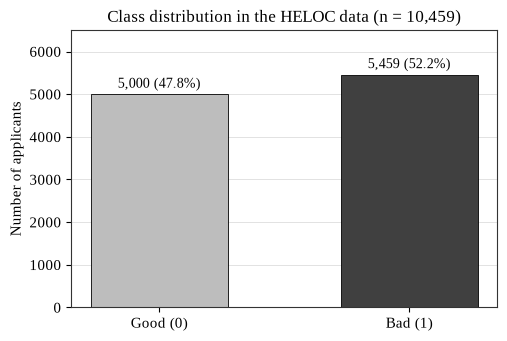

In [4]:
fig, ax = plt.subplots(figsize=(5.5, 3.6))
vals = [counts["Good"], counts["Bad"]]
bars = ax.bar(["Good (0)", "Bad (1)"], vals, color=["#bdbdbd", "#404040"], edgecolor="black", linewidth=0.6, width=0.55)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 80, f"{v:,} ({v/len(df):.1%})", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Number of applicants"); ax.set_ylim(0, 6500)
ax.set_title("Class distribution in the HELOC data (n = 10,459)")
ax.grid(axis="x", visible=False)
plt.savefig("figures/fig_class_distribution.png"); plt.show()

## Step 3: Look at the special codes (-7, -8, -9)

**What they are:** some boxes in the data hold a *code* instead of a real number:

* **-9**: no credit bureau record at all,
* **-8**: no usable or valid accounts or inquiries,
* **-7**: condition not met (for example, *no* late payment ever, or *no* recent inquiry).

**Why it matters:** these codes are not real amounts. A value of -7 months does not exist. If we fed them to the model as ordinary numbers, the model might think "-7 months" is just a very small number of months. So we need to handle them on purpose (Step 4).

In [5]:
code_table = pd.DataFrame({c: {k: int((X_raw[c] == k).sum()) for k in [-9, -8, -7]} for c in FEATURES}).T
code_table.columns = ["-9 (no bureau record)", "-8 (no usable trades)", "-7 (condition not met)"]
code_table = code_table[code_table.sum(axis=1) > 0]
all_minus9 = int((X_raw == -9).all(axis=1).sum())
print("Rows where EVERY feature is -9 (no bureau record at all):", all_minus9)
code_table

Rows where EVERY feature is -9 (no bureau record at all): 588


,-9 (no bureau record),-8 (no usable trades),-7 (condition not met)
ExternalRiskEstimate,598,0,0
MSinceOldestTradeOpen,588,239,0
MSinceMostRecentTradeOpen,588,0,0
AverageMInFile,588,0,0
NumSatisfactoryTrades,588,0,0
NumTrades60Ever2DerogPubRec,588,0,0
NumTrades90Ever2DerogPubRec,588,0,0
PercentTradesNeverDelq,588,0,0
MSinceMostRecentDelq,588,176,4664
MaxDelq2PublicRecLast12M,588,0,0


**What the result means:** **588 people** have `-9` in every single box: the bureau had no file on them. Some features carry many codes, for example `MSinceMostRecentDelq` (months since the last late payment) is `-7` for 4,664 people, meaning they **never** had a late payment.

## Step 4: Weight of Evidence (WoE) for the special codes

**The idea in simple words:** for each code, we ask: *"Out of the people with this code, are there more Good people or more Bad people than usual?"* Then we replace the code with a single score:

$$\text{WoE} = \ln\left(\frac{(\text{Good with this code} + 0.5)\,/\,\text{all Good}}{(\text{Bad with this code} + 0.5)\,/\,\text{all Bad}}\right)$$

* A **positive** WoE means the code is linked with **safer** people.
* A **negative** WoE means the code is linked with **riskier** people.
* The `+ 0.5` stops the formula from breaking when a group has zero people.

**Important honest detail:** only the special codes are replaced. The ordinary numbers (for example 72 for `ExternalRiskEstimate`) stay exactly as they are. Following the original dissertation run, the WoE scores are calculated from the whole file. Step 11 tests what happens if they are calculated from the training part only.

In [6]:
CODES = [-9, -8, -7]

def build_woe_map(X, y):
    # Return {feature: {code: WoE}} for every special code found in X.
    total_bad = y.sum(); total_good = len(y) - total_bad
    woe_map = {}
    for col in X.columns:
        if X[col].min() < 0:
            woe_map[col] = {}
            for code in CODES:
                mask = X[col] == code
                if mask.any():
                    n_bad = y[mask].sum(); n_good = mask.sum() - n_bad
                    woe_map[col][code] = float(np.log(((n_good + 0.5) / total_good) / ((n_bad + 0.5) / total_bad)))
    return woe_map

def apply_woe(X, woe_map):
    # Replace each special code by its WoE score; real values are untouched.
    X = X.copy().astype(float)
    for col, codes in woe_map.items():
        for code, w in codes.items():
            X.loc[X[col] == code, col] = w
    return X

t0 = time.time()
WOE_MAP = build_woe_map(X_raw, y_all)
X_woe = apply_woe(X_raw, WOE_MAP)
woe_tbl = pd.DataFrame(WOE_MAP).T.round(4)
woe_tbl.columns = [f"code {c}" for c in woe_tbl.columns]
woe_tbl

,code -9,code -8,code -7
ExternalRiskEstimate,-0.1267,NaN,NaN
MSinceOldestTradeOpen,-0.1098,-0.0708,NaN
MSinceMostRecentTradeOpen,-0.1098,NaN,NaN
AverageMInFile,-0.1098,NaN,NaN
NumSatisfactoryTrades,-0.1098,NaN,NaN
NumTrades60Ever2DerogPubRec,-0.1098,NaN,NaN
NumTrades90Ever2DerogPubRec,-0.1098,NaN,NaN
PercentTradesNeverDelq,-0.1098,NaN,NaN
MSinceMostRecentDelq,-0.1098,-0.2778,0.4982
MaxDelq2PublicRecLast12M,-0.1098,NaN,NaN


**What the result means:** look at the row for `MSinceMostRecentInqexcl7days` (months since the last credit check). Code **-8** ("no usable or valid inquiries", 476 people) gets **+1.6674**, a strongly *safe* signal: people with this code repay more often than average. Code **-7** in the same feature gets **-0.3739**, a *riskier* signal. In `MSinceMostRecentDelq` (months since the last late payment), code **-7** (never late, 4,664 people) gets **+0.4982**: safer, as common sense expects. The code **-9** ("no bureau record") gets **-0.1098** in most features and **-0.1267** in `ExternalRiskEstimate`: slightly *riskier* than average.

**A subtle point to remember for later (Step 16):** the WoE score sits on the same number line as the real values. For example, +1.6674 sits between a real value of 1 month and 2 months. The trees can learn a special "pocket" around 1.6674. This is why the counterfactual search in Step 16 works on whole numbers in the original units.

## Step 5: Split into training and test parts, then balance the training part with SMOTE

**Why split:** we keep **20%** of the people hidden from the model (the *test set*). It is like keeping some exam questions secret: the model studies on 80% and is marked on the 20% it has never seen. The split is *stratified*, so both parts keep the same share of Good and Bad.

**Why SMOTE:** SMOTE (Synthetic Minority Over-sampling Technique) makes extra, *made-up but realistic* rows for the smaller group, by drawing a point on the straight line between one real person and one of their 5 nearest look-alikes. Here the smaller group in training is **Good**, so SMOTE creates extra Good rows until Good and Bad are equal.

**The key rule:** SMOTE touches the **training part only**. The test part stays real and untouched, so the marks we give the model are honest.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_woe, y_all, test_size=0.2, random_state=RANDOM_STATE, stratify=y_all)
smote = SMOTE(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
TIMINGS["Preprocessing (WoE + split + SMOTE)"] = time.time() - t0
X_train_raw, X_test_raw = X_raw.loc[X_train.index], X_raw.loc[X_test.index]

split_tbl = pd.DataFrame({
    "Rows": [len(X_train), len(X_train_bal), len(X_test)],
    "Good (0)": [int((y_train == 0).sum()), int((y_train_bal == 0).sum()), int((y_test == 0).sum())],
    "Bad (1)": [int((y_train == 1).sum()), int((y_train_bal == 1).sum()), int((y_test == 1).sum())],
}, index=["Training (before SMOTE)", "Training (after SMOTE)", "Test (untouched)"])
print("Synthetic Good rows created by SMOTE:", len(X_train_bal) - len(X_train))
split_tbl

Synthetic Good rows created by SMOTE: 367


,Rows,Good (0),Bad (1)
Training (before SMOTE),8367,4000,4367
Training (after SMOTE),8734,4367,4367
Test (untouched),2092,1000,1092


**What the result means:**

* Training before SMOTE: **8,367** people (4,000 Good, 4,367 Bad).
* SMOTE adds **367** synthetic **Good** rows, giving **8,734** rows (4,367 Good, 4,367 Bad).
* Test set: **2,092** real people (1,000 Good, 1,092 Bad), never touched by SMOTE.

## Step 6: Baseline models (the "simple students" we compare against)

**Why:** to claim the tuned XGBoost is good, we must compare it with simpler models trained on exactly the same data:

i. **Logistic Regression**: one straight-line rule (features are first put on the same scale, which this method needs).
ii. **Random Forest (100 trees)**: many independent trees that vote.
iii. **XGBoost with default settings**: the same algorithm as our final model, but without tuning.

We record four scores (explained fully in Step 9) and the training time.

In [8]:
def ks_stat(y_true, p):
    fpr, tpr, _ = roc_curve(y_true, p)
    return float(np.max(tpr - fpr))

baselines = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    "Random Forest (100 trees)": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost (default settings)": xgb.XGBClassifier(random_state=RANDOM_STATE, use_label_encoder=False, n_jobs=-1),
}
base_rows, base_proba = [], {}
for name, mdl in baselines.items():
    t = time.time(); mdl.fit(X_train_bal, y_train_bal); fit_s = time.time() - t
    p = mdl.predict_proba(X_test)[:, 1]; base_proba[name] = p
    auc = roc_auc_score(y_test, p)
    base_rows.append({"Model": name, "AUC-ROC": auc, "Gini": 2*auc - 1, "KS": ks_stat(y_test, p),
                      "F1": f1_score(y_test, (p >= 0.5).astype(int)), "Training time (s)": fit_s})
base_df = pd.DataFrame(base_rows).set_index("Model")
base_df.round(4)

,AUC-ROC,Gini,KS,F1,Training time (s)
Model,,,,,
Logistic Regression,0.7669,0.5338,0.4067,0.7074,0.2662
Random Forest (100 trees),0.7898,0.5795,0.4344,0.7405,0.9670
XGBoost (default settings),0.7719,0.5439,0.4187,0.7282,0.7806


## Step 7: Tune XGBoost with Optuna (Bayesian search, 20 trials)

**The idea in simple words:** XGBoost has *knobs* (settings). Turning them changes how well it learns. Instead of trying every combination (too slow), **Optuna** uses the **Tree-structured Parzen Estimator (TPE)**: it looks at the trials so far, builds a picture of which knob values gave good scores, and picks the next trial where a good score looks most likely. The first 10 trials are random exploration; the next 10 use what was learned.

**The five knobs:**

| Knob | Plain meaning | Range searched |
|---|---|---|
| `max_depth` | how many questions each tree may ask in a row | 3 to 8 |
| `learning_rate` | how big a step each new tree takes when fixing mistakes | 0.01 to 0.3 (log scale) |
| `n_estimators` | how many trees in the team | 100 to 500, in steps of 50 |
| `subsample` | share of rows each tree sees (adds healthy randomness) | 0.6 to 1.0 |
| `colsample_bytree` | share of features each tree sees | 0.6 to 1.0 |

**How each trial is marked:** 3-fold stratified cross-validation on the balanced training set. The data is cut into 3 parts; the model trains on 2 and is scored (AUC) on the third, three times, and the 3 scores are averaged. **The test set is never used for tuning.**

In [9]:
def objective(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 100, 500, step=50),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "random_state": RANDOM_STATE, "use_label_encoder": False, "n_jobs": -1,
    }
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    for tr_idx, va_idx in cv.split(X_train_bal, y_train_bal):
        m = xgb.XGBClassifier(**params)
        m.fit(X_train_bal.iloc[tr_idx], y_train_bal.iloc[tr_idx], verbose=False)
        scores.append(roc_auc_score(y_train_bal.iloc[va_idx], m.predict_proba(X_train_bal.iloc[va_idx])[:, 1]))
    return float(np.mean(scores))

optuna.logging.set_verbosity(optuna.logging.WARNING)
t = time.time()
study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=20)
TIMINGS["Hyperparameter optimisation (20 trials x 3 folds)"] = time.time() - t
print(f"Best mean CV AUC = {study.best_value:.4f} (trial {study.best_trial.number})")
print("Best settings:", study.best_params)
trials_df = study.trials_dataframe()[["number", "value", "params_max_depth", "params_learning_rate",
                                      "params_n_estimators", "params_subsample", "params_colsample_bytree"]]
trials_df.columns = ["Trial", "CV AUC", "max_depth", "learning_rate", "n_estimators", "subsample", "colsample_bytree"]
trials_df.round(4)

Best mean CV AUC = 0.8066 (trial 3)
Best settings: {'max_depth': 4, 'learning_rate': 0.028145092716060652, 'n_estimators': 300, 'subsample': 0.7727780074568463, 'colsample_bytree': 0.7164916560792167}


,Trial,CV AUC,max_depth,learning_rate,n_estimators,subsample,colsample_bytree
0,0,0.7786,5,0.2537,400,0.8395,0.6624
1,1,0.8044,3,0.0122,450,0.8404,0.8832
2,2,0.7801,3,0.2708,450,0.6849,0.6727
3,3,0.8066,4,0.0281,300,0.7728,0.7165
4,4,0.8049,6,0.0161,200,0.7465,0.7824
5,5,0.8048,7,0.0197,300,0.8370,0.6186
6,6,0.8003,6,0.0179,100,0.9796,0.9863
7,7,0.8037,7,0.0282,100,0.8737,0.7761
8,8,0.8043,3,0.0539,100,0.9637,0.7035
9,9,0.8052,6,0.0289,300,0.8187,0.6739


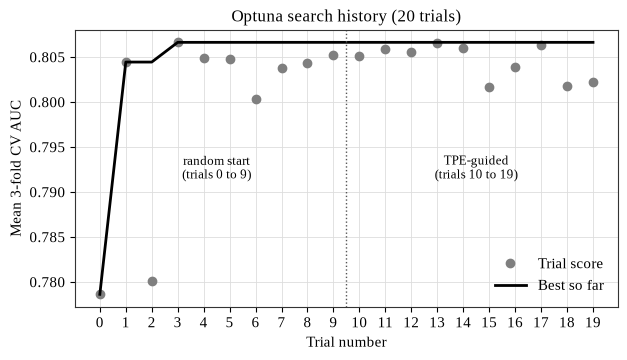

In [10]:
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(trials_df["Trial"], trials_df["CV AUC"], "o", color="#7f7f7f", markersize=6, label="Trial score")
ax.plot(trials_df["Trial"], trials_df["CV AUC"].cummax(), "-", color="black", linewidth=2, label="Best so far")
ax.axvline(9.5, color="#555555", linestyle=":", linewidth=1)
ax.text(4.5, 0.7915, "random start\n(trials 0 to 9)", ha="center", fontsize=9)
ax.text(14.5, 0.7915, "TPE-guided\n(trials 10 to 19)", ha="center", fontsize=9)
ax.set_xlabel("Trial number"); ax.set_ylabel("Mean 3-fold CV AUC"); ax.set_xticks(range(0, 20))
ax.set_title("Optuna search history (20 trials)"); ax.legend(loc="lower right", frameon=False)
plt.savefig("figures/fig_optuna_history.png"); plt.show()

**What the result means:** the best settings were found at **trial 3** (mean CV AUC **0.8066**): `max_depth = 4`, `learning_rate = 0.0281`, `n_estimators = 300`, `subsample = 0.7728`, `colsample_bytree = 0.7165`. The guided trials (10 to 19) came close (0.8065 at trial 13) but did not beat it. This is normal: with only 20 trials, a lucky early random trial can stay the best. All 20 trials scored between 0.7786 and 0.8066, which suggests the model is not very sensitive to these knobs inside the searched ranges.

## Step 8: Train the final model and save it

**Why:** we now train one XGBoost on the **whole balanced training set** with the best settings, and save it as `model.pkl`. This is the exact file the web app loads.

**Reproducibility check:** if the original `model.pkl` from the GitHub repository is in the folder (renamed `model_repo.pkl`), we compare the predictions of both models on the test set. If the largest difference is 0, the new run rebuilt the original model exactly.

In [11]:
final_params = study.best_params.copy()
final_params.update({"random_state": RANDOM_STATE, "use_label_encoder": False, "n_jobs": -1})
t = time.time()
model = xgb.XGBClassifier(**final_params)
model.fit(X_train_bal, y_train_bal)
TIMINGS["Final XGBoost training"] = time.time() - t
joblib.dump(model, "model.pkl")
print("Final model trained and saved as model.pkl")
if os.path.exists("model_repo.pkl"):
    repo_model = joblib.load("model_repo.pkl")
    diff = np.abs(repo_model.predict_proba(X_test)[:, 1] - model.predict_proba(X_test)[:, 1]).max()
    print(f"Largest difference from the GitHub model.pkl on the 2,092 test applicants: {diff:.10f}")

Final model trained and saved as model.pkl
Largest difference from the GitHub model.pkl on the 2,092 test applicants: 0.0000000000


## Step 9: Mark the final model on the hidden test set

**The scores in plain English:**

* **AUC-ROC:** pick one Bad person and one Good person at random. AUC is the chance the model gives the Bad person the higher risk score. 0.5 is coin-flipping; 1.0 is perfect.
* **Gini:** the same information stretched to run from 0 to 1: Gini = 2 x AUC - 1. Banks like this form.
* **KS (Kolmogorov-Smirnov):** the biggest gap between the share of Bad people and the share of Good people caught as we slowly raise the risk cut-off. Bigger gap = better separation.
* **Accuracy:** share of all decisions that are right.
* **Precision:** of the people the model calls Bad (rejects), how many really are Bad.
* **Recall:** of all the people who really are Bad, how many the model catches.
* **F1:** one number that balances precision and recall.

The decision rule is the **default cut-off of 0.5**: if the predicted chance of Bad is 0.5 or more, the person is rejected. This cut-off was not tuned.

In [12]:
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)
auc = roc_auc_score(y_test, y_proba)
fpr, tpr, thr = roc_curve(y_test, y_proba)
metrics = {"auc": float(auc), "gini": float(2*auc - 1), "ks": float(np.max(tpr - fpr)),
           "acc": float(accuracy_score(y_test, y_pred)), "prec": float(precision_score(y_test, y_pred)),
           "rec": float(recall_score(y_test, y_pred)), "f1": float(f1_score(y_test, y_pred))}
rng = np.random.RandomState(RANDOM_STATE); boot = []
yt, yp_ = y_test.values, y_proba
for _ in range(1000):
    idx = rng.randint(0, len(yt), len(yt))
    if len(np.unique(yt[idx])) == 2: boot.append(roc_auc_score(yt[idx], yp_[idx]))
ci_low, ci_high = np.percentile(boot, [2.5, 97.5])
metrics.update({"auc_ci_low": float(ci_low), "auc_ci_high": float(ci_high)})
with open("metrics.json", "w") as f: json.dump(metrics, f, indent=2)
labels = {"auc": "AUC-ROC", "gini": "Gini coefficient", "ks": "KS statistic", "acc": "Accuracy",
          "prec": "Precision", "rec": "Recall (sensitivity)", "f1": "F1-score"}
for k, lab in labels.items(): print(f"{lab:22s} {metrics[k]:.4f}")
print(f"95% bootstrap interval for AUC (1,000 resamples): {ci_low:.4f} to {ci_high:.4f}")

AUC-ROC                0.7933
Gini coefficient       0.5865
KS statistic           0.4433
Accuracy               0.7213
Precision              0.7192
Recall (sensitivity)   0.7647
F1-score               0.7412
95% bootstrap interval for AUC (1,000 resamples): 0.7742 to 0.8125


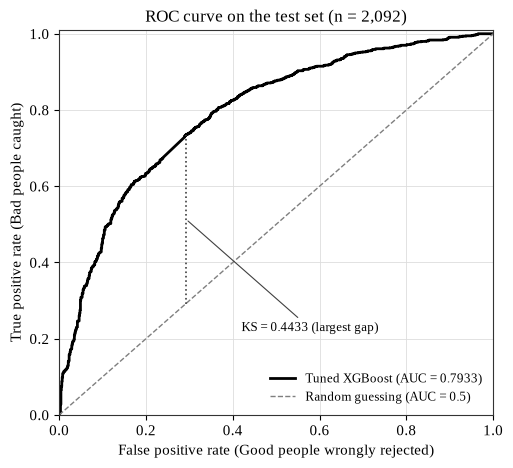

In [13]:
fig, ax = plt.subplots(figsize=(5.6, 5))
ax.plot(fpr, tpr, color="black", linewidth=2, label=f"Tuned XGBoost (AUC = {auc:.4f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="#7f7f7f", linewidth=1, label="Random guessing (AUC = 0.5)")
k = int(np.argmax(tpr - fpr))
ax.plot([fpr[k], fpr[k]], [fpr[k], tpr[k]], color="#404040", linewidth=1.2, linestyle=":")
ax.annotate(f"KS = {tpr[k]-fpr[k]:.4f} (largest gap)", (fpr[k], (fpr[k]+tpr[k])/2), xytext=(0.42, 0.22),
            fontsize=9, arrowprops=dict(arrowstyle="-", color="#404040", lw=0.8))
ax.set_xlabel("False positive rate (Good people wrongly rejected)")
ax.set_ylabel("True positive rate (Bad people caught)")
ax.set_title("ROC curve on the test set (n = 2,092)"); ax.legend(loc="lower right", frameon=False, fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.01)
plt.savefig("figures/fig_roc.png"); plt.show()

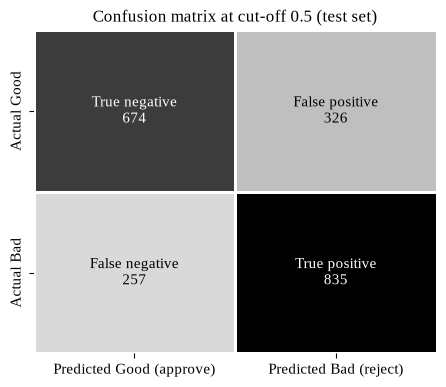

TN = 674, FP = 326, FN = 257, TP = 835
Bad people missed (false negative rate) = 257/1092 = 23.53%
Good people wrongly rejected (false positive rate) = 326/1000 = 32.60%


In [14]:
cm = confusion_matrix(y_test, y_pred); tn, fp, fn, tp = cm.ravel()
fig, ax = plt.subplots(figsize=(5.2, 4.2))
sns.heatmap(cm, annot=False, cmap=GREY_CMAP, cbar=False, linewidths=1, linecolor="white", ax=ax)
names = [["True negative", "False positive"], ["False negative", "True positive"]]
for i in range(2):
    for j in range(2):
        ax.text(j + 0.5, i + 0.5, f"{names[i][j]}\n{cm[i, j]}", ha="center", va="center", fontsize=11,
                color="white" if cm[i, j] > 500 else "black")
ax.set_xticklabels(["Predicted Good (approve)", "Predicted Bad (reject)"])
ax.set_yticklabels(["Actual Good", "Actual Bad"], rotation=90, va="center")
ax.set_title("Confusion matrix at cut-off 0.5 (test set)")
plt.savefig("figures/fig_confusion.png"); plt.show()
print(f"TN = {tn}, FP = {fp}, FN = {fn}, TP = {tp}")
print(f"Bad people missed (false negative rate) = {fn}/{fn+tp} = {fn/(fn+tp):.2%}")
print(f"Good people wrongly rejected (false positive rate) = {fp}/{fp+tn} = {fp/(fp+tn):.2%}")

**What the results mean:**

* **AUC = 0.7933**: about 79 times out of 100, a randomly chosen Bad person gets a higher risk score than a randomly chosen Good person. The 95% bootstrap interval (printed above) shows the range this score could reasonably take on a different sample of 2,092 people.
* **Gini = 0.5865** and **KS = 0.4433**: clear separation between the two groups.
* **Confusion matrix:** 674 Good people correctly approved, 326 Good people wrongly rejected, 257 Bad people wrongly approved and 835 Bad people correctly rejected.
* **Recall = 0.7647**: the model catches about 76 of every 100 Bad people. **Precision = 0.7192**: about 72 of every 100 people it rejects really are Bad.

## Step 10: Compare with the baselines and test whether the gaps are real (DeLong test)

**Why:** a small difference in AUC might just be luck in who ended up in the test set. The **DeLong test** checks whether two AUCs measured on the **same people** are truly different. It gives a *p-value*: if p is below 0.05, the gap is unlikely to be pure luck; if p is 0.05 or more, we cannot claim a real difference.

In [15]:
def _midrank(x):
    order = np.argsort(x); z = x[order]; n = len(x); t = np.zeros(n); i = 0
    while i < n:
        j = i
        while j < n and z[j] == z[i]: j += 1
        t[i:j] = 0.5 * (i + j - 1) + 1
        i = j
    out = np.empty(n); out[order] = t
    return out

def delong_test(y_true, p1, p2):
    # Paired DeLong test for two correlated AUCs. Returns (auc1, auc2, z, p_value).
    y_true = np.asarray(y_true); order = np.argsort(-y_true, kind="mergesort")
    preds = np.vstack([p1, p2])[:, order]; m = int(y_true.sum()); n = preds.shape[1] - m
    tx = np.array([_midrank(r[:m]) for r in preds]); ty = np.array([_midrank(r[m:]) for r in preds])
    tz = np.array([_midrank(r) for r in preds])
    aucs = tz[:, :m].sum(axis=1) / m / n - (m + 1.0) / 2.0 / n
    v01 = (tz[:, :m] - tx) / n; v10 = 1.0 - (tz[:, m:] - ty) / m
    cov = np.cov(v01) / m + np.cov(v10) / n
    z = (aucs[0] - aucs[1]) / np.sqrt(cov[0, 0] + cov[1, 1] - 2 * cov[0, 1])
    return aucs[0], aucs[1], float(z), float(2 * (1 - norm.cdf(abs(z))))

comp = base_df.copy()
comp.loc["XGBoost (tuned, final)"] = {"AUC-ROC": metrics["auc"], "Gini": metrics["gini"], "KS": metrics["ks"],
                                      "F1": metrics["f1"], "Training time (s)": TIMINGS["Final XGBoost training"]}
rows = []
for name, p in base_proba.items():
    a1, a2, z, pv = delong_test(y_test, y_proba, p)
    rows.append({"Comparison": f"Tuned XGBoost vs {name}", "AUC difference": a1 - a2, "z": z, "p-value": pv,
                 "Real difference at 0.05?": "Yes" if pv < 0.05 else "No"})
delong_df = pd.DataFrame(rows).set_index("Comparison")
display(comp.round(4)); display(delong_df.round(4))

,AUC-ROC,Gini,KS,F1,Training time (s)
Model,,,,,
Logistic Regression,0.7669,0.5338,0.4067,0.7074,0.2662
Random Forest (100 trees),0.7898,0.5795,0.4344,0.7405,0.9670
XGBoost (default settings),0.7719,0.5439,0.4187,0.7282,0.7806
"XGBoost (tuned, final)",0.7933,0.5865,0.4433,0.7412,1.6200


,AUC difference,z,p-value,Real difference at 0.05?
Comparison,,,,
Tuned XGBoost vs Logistic Regression,0.0264,4.6597,0.0000,Yes
Tuned XGBoost vs Random Forest (100 trees),0.0035,1.0333,0.3015,No
Tuned XGBoost vs XGBoost (default settings),0.0213,4.5331,0.0000,Yes


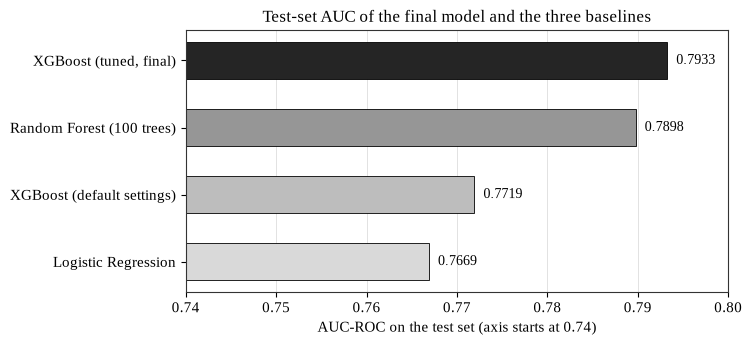

In [16]:
fig, ax = plt.subplots(figsize=(7, 3.4))
order_names = ["Logistic Regression", "XGBoost (default settings)", "Random Forest (100 trees)", "XGBoost (tuned, final)"]
vals = [comp.loc[n, "AUC-ROC"] for n in order_names]
shades = ["#d9d9d9", "#bdbdbd", "#969696", "#252525"]
bars = ax.barh(order_names, vals, color=shades, edgecolor="black", linewidth=0.6, height=0.55)
for b, v in zip(bars, vals): ax.text(v + 0.001, b.get_y() + b.get_height()/2, f"{v:.4f}", va="center", fontsize=10)
ax.set_xlim(0.74, 0.80); ax.set_xlabel("AUC-ROC on the test set (axis starts at 0.74)")
ax.set_title("Test-set AUC of the final model and the three baselines"); ax.grid(axis="y", visible=False)
plt.savefig("figures/fig_baselines.png"); plt.show()

**What the result means:** the tuned XGBoost has the highest AUC (0.7933). The gap over **Logistic Regression** and over **default XGBoost** is real (p below 0.05). The gap over **Random Forest** is small (about 0.0035) and the DeLong test **cannot** show it is real (p well above 0.05). So the honest statement is: *the tuned XGBoost clearly beats logistic regression and untuned XGBoost, and performs about the same as a 100-tree random forest on this test set.* XGBoost is still a sensible choice for the framework because TreeSHAP computes its exact Shapley values quickly.

## Step 11: Two design checks (to show the choices were tested, not just assumed)

**Check A, WoE from training data only.** In Step 4, the WoE scores were calculated from the whole file, including the test people. In strict practice, anything learned from the answers should come from the training part only, otherwise a little information from the test set "leaks" into the model. Here we rebuild the WoE scores from the training rows only and retrain with the same settings.

**Check B, special codes as "missing".** XGBoost can handle empty (missing) values by itself: at every split it learns which way the empty values should go. Here we turn every special code into an empty value instead of a WoE score.

**Check C, no SMOTE at all.** The data is almost balanced (52% Bad, 48% Good), so we also train on the 8,367 real training rows only.

**Check D, SMOTE rows rounded to whole numbers.** SMOTE's synthetic rows hold decimals (for example 0.0024 inquiries) that no real person can have. Here every synthetic value that is not a WoE score is rounded to the nearest whole number before training. Step 20 explains why this matters for stability; here we only check the AUC.

If the AUC barely moves, the original design choice did not create a hidden advantage.

In [17]:
def fit_eval(Xtr, ytr, Xte, yte):
    Xb, yb = SMOTE(random_state=RANDOM_STATE).fit_resample(Xtr, ytr)
    m = xgb.XGBClassifier(**final_params).fit(Xb, yb)
    return roc_auc_score(yte, m.predict_proba(Xte)[:, 1])

woe_map_train = build_woe_map(X_train_raw, y_train)
auc_a = fit_eval(apply_woe(X_train_raw, woe_map_train), y_train, apply_woe(X_test_raw, woe_map_train), y_test)
Xtr_nan = X_train_raw.astype(float).mask(X_train_raw < 0); Xte_nan = X_test_raw.astype(float).mask(X_test_raw < 0)
Xtr_nan_imp = Xtr_nan.fillna(-1)   # SMOTE cannot take empty values, so we use a placeholder during SMOTE only
Xb, yb = SMOTE(random_state=RANDOM_STATE).fit_resample(Xtr_nan_imp, y_train)
Xb = Xb.mask(Xb < 0)               # turn the placeholder back into missing for XGBoost
auc_b = roc_auc_score(y_test, xgb.XGBClassifier(**final_params).fit(Xb, yb).predict_proba(Xte_nan)[:, 1])
auc_c = roc_auc_score(y_test, xgb.XGBClassifier(**final_params).fit(X_train, y_train).predict_proba(X_test)[:, 1])
woe_values = {c: set(np.round(list(WOE_MAP.get(c, {}).values()), 10)) for c in FEATURES}
X_round = X_train_bal.copy()
synthetic = np.arange(len(X_round)) >= len(X_train)          # SMOTE appends its synthetic rows at the end
for c in FEATURES:
    v = X_round.loc[synthetic, c]
    is_woe = np.round(v, 10).isin(woe_values[c])
    X_round.loc[synthetic, c] = np.where(is_woe, v, np.round(v))
model_round = xgb.XGBClassifier(**final_params).fit(X_round, y_train_bal)
auc_d = roc_auc_score(y_test, model_round.predict_proba(X_test)[:, 1])
design_df = pd.DataFrame({"Test AUC": [metrics["auc"], auc_a, auc_b, auc_c, auc_d]},
    index=["Original design (WoE from full file)", "Check A: WoE from training rows only", "Check B: special codes as missing",
           "Check C: no SMOTE (real rows only)", "Check D: SMOTE rows rounded to whole numbers"])
design_df["Change vs original"] = design_df["Test AUC"] - metrics["auc"]
design_df.round(4)

,Test AUC,Change vs original
Original design (WoE from full file),0.7933,0.0000
Check A: WoE from training rows only,0.7942,0.0009
Check B: special codes as missing,0.7937,0.0004
Check C: no SMOTE (real rows only),0.7938,0.0005
Check D: SMOTE rows rounded to whole numbers,0.7924,-0.0009


**What the result means:** all five AUCs sit between 0.7924 and 0.7942, a band of less than 0.002. So (i) computing WoE on the whole file did not give the model a hidden advantage (Check A), (ii) the WoE choice works about as well as XGBoost's own handling of empty values (Check B), (iii) SMOTE is not what drives the result on this nearly balanced data (Check C), and (iv) rounding the synthetic rows costs almost nothing in AUC (Check D) while, as Step 20 shows, it removes a stability problem.

## Step 12: Open the box with TreeSHAP (global explanation)

**The idea in simple words:** imagine the 23 features are players on a football team and the prediction is the score. **Shapley values** share out the credit for the score fairly among the players, by checking how much each player adds on average across every possible line-up. **TreeSHAP** is a fast, exact way to compute these values for tree models like XGBoost.

* Each person gets one SHAP value per feature.
* A **positive** SHAP value pushes the prediction **towards Bad** (more risk); a **negative** value pushes **towards Good**.
* For XGBoost, SHAP values are in **log-odds** units (the model's internal score before it is turned into a probability).
* The **global importance** of a feature is the **average size** (ignoring the sign) of its SHAP values over all 2,092 test people.

In [18]:
t = time.time()
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
TIMINGS["TreeSHAP values for the test set (n = 2,092)"] = time.time() - t
print("Base value (average model output in log-odds):", round(float(explainer.expected_value), 4))
shap_imp = pd.Series(np.abs(shap_values).mean(axis=0), index=FEATURES).sort_values(ascending=False)
shap_tbl = pd.DataFrame({"Rank": range(1, 24), "Mean |SHAP|": shap_imp.round(4),
                         "Share of total": (shap_imp / shap_imp.sum()).round(4)})
shap_tbl

Base value (average model output in log-odds): -0.0018


,Rank,Mean |SHAP|,Share of total
ExternalRiskEstimate,1,0.5381,0.2341
MSinceMostRecentInqexcl7days,2,0.3267,0.1421
NetFractionRevolvingBurden,3,0.2462,0.1071
AverageMInFile,4,0.1955,0.0850
PercentTradesNeverDelq,5,0.1561,0.0679
PercentInstallTrades,6,0.1383,0.0602
NumSatisfactoryTrades,7,0.1327,0.0577
NumRevolvingTradesWBalance,8,0.0702,0.0305
PercentTradesWBalance,9,0.0566,0.0246
MSinceOldestTradeOpen,10,0.0545,0.0237


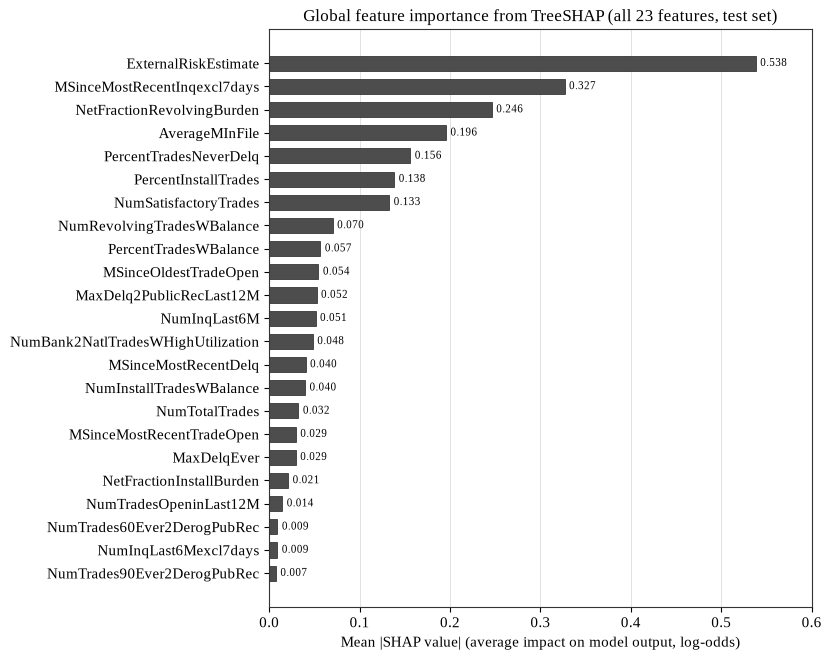

In [19]:
fig, ax = plt.subplots(figsize=(7, 7.5))
s = shap_imp.iloc[::-1]
ax.barh(s.index, s.values, color="#4d4d4d", edgecolor="black", linewidth=0.4, height=0.65)
for i, v in enumerate(s.values): ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=8)
ax.set_xlabel("Mean |SHAP value| (average impact on model output, log-odds)")
ax.set_title("Global feature importance from TreeSHAP (all 23 features, test set)")
ax.grid(axis="y", visible=False); ax.set_xlim(0, 0.6)
plt.savefig("figures/fig_shap_importance.png"); plt.show()

**What the result means:** the top five features are **ExternalRiskEstimate (0.5381)**, **MSinceMostRecentInqexcl7days (0.3267)**, **NetFractionRevolvingBurden (0.2462)**, **AverageMInFile (0.1955)** and **PercentTradesNeverDelq (0.1561)**. `ExternalRiskEstimate` (the bureau's own summary score) matters about 1.65 times as much as the second feature. The weakest features are `NumTrades90Ever2DerogPubRec` (0.0074), `NumInqLast6Mexcl7days` (0.0090) and `NumTrades60Ever2DerogPubRec` (0.0091).

### The beeswarm plot (direction of each effect)

Each dot is one test person. Left or right shows the SHAP value (left = pushes towards Good, right = pushes towards Bad). The shade shows the feature's own value: **dark = high value**, **light = low value**.

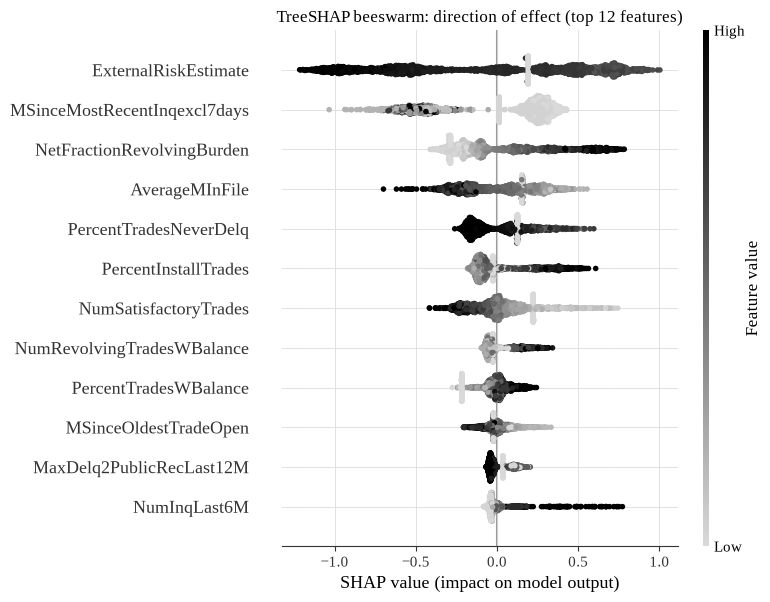

In [20]:
plt.figure()
shap.summary_plot(shap_values, X_test, max_display=12, cmap=GREY_CMAP, show=False, plot_size=(8, 6))
plt.title("TreeSHAP beeswarm: direction of effect (top 12 features)")
plt.savefig("figures/fig_shap_beeswarm.png"); plt.show()

**How to read it:** for `ExternalRiskEstimate`, dark dots (high bureau scores) sit on the **left** (safer) and lighter dots (low scores) on the **right** (riskier). For `NetFractionRevolvingBurden` (how much of the card limit is used), dark dots (high use) sit on the **right**: using more of your limit raises risk. For `MSinceMostRecentInqexcl7days`, the big pale cluster on the **right** is people whose last credit check was 0 months ago (very recent, riskier); people whose last check was longer ago sit on the **left** (safer). The thin vertical stripes of identical dots are people who share the same special code, so they all get the same push. Because WoE scores are small numbers, coded people are shaded as "low" values; keep that in mind when reading the shades.

### Dependence plot and interaction (Section 4.4.3)

Here we look at how the effect of `ExternalRiskEstimate` changes with its value, shaded by `MSinceMostRecentInqexcl7days`. People with a special code in either feature are left out of this picture, so the x-axis shows only real values. We also measure how strong the **interaction** between the two features is, using SHAP interaction values on 500 test people.

<Figure size 640x480 with 0 Axes>

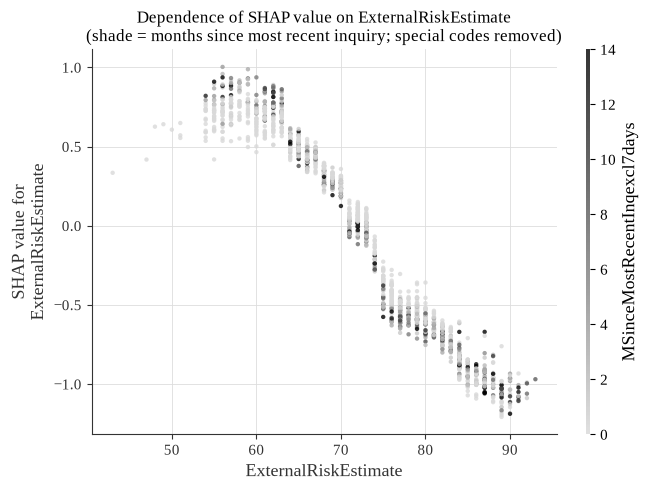

Mean |main effect| ExternalRiskEstimate = 0.6274
Mean |main effect| MSinceMostRecentInqexcl7days = 0.3548
Mean |interaction| between the two = 0.0759  (7.7% of their combined main effects)
Strongest interacting pair overall: MSinceMostRecentInqexcl7days x ExternalRiskEstimate = 0.0759


In [21]:
real = (X_test_raw["ExternalRiskEstimate"] >= 0) & (X_test_raw["MSinceMostRecentInqexcl7days"] >= 0)
plt.figure()
shap.dependence_plot("ExternalRiskEstimate", shap_values[real.values], X_test[real], interaction_index="MSinceMostRecentInqexcl7days",
                     cmap=GREY_CMAP, show=False, dot_size=10, alpha=0.8)
plt.title("Dependence of SHAP value on ExternalRiskEstimate\n(shade = months since most recent inquiry; special codes removed)")
plt.savefig("figures/fig_shap_dependence.png"); plt.show()

t = time.time()
sub = X_test.iloc[:500]
inter = explainer.shap_interaction_values(sub)
TIMINGS["TreeSHAP interaction values (500 applicants)"] = time.time() - t
i1, i2 = FEATURES.index("ExternalRiskEstimate"), FEATURES.index("MSinceMostRecentInqexcl7days")
inter_strength = float(np.abs(inter[:, i1, i2] * 2).mean())
main1, main2 = float(np.abs(inter[:, i1, i1]).mean()), float(np.abs(inter[:, i2, i2]).mean())
pair_strength = np.abs(inter).mean(axis=0) * 2; np.fill_diagonal(pair_strength, 0)
top_pair = np.unravel_index(np.argmax(pair_strength), pair_strength.shape)
print(f"Mean |main effect| ExternalRiskEstimate = {main1:.4f}")
print(f"Mean |main effect| MSinceMostRecentInqexcl7days = {main2:.4f}")
print(f"Mean |interaction| between the two = {inter_strength:.4f}  ({inter_strength/(main1+main2):.1%} of their combined main effects)")
print(f"Strongest interacting pair overall: {FEATURES[top_pair[0]]} x {FEATURES[top_pair[1]]} = {pair_strength[top_pair]:.4f}")

**What the result means:** from a score of about 56 upwards, the SHAP value of `ExternalRiskEstimate` falls steadily as the score rises: higher bureau scores mean lower risk. The shading does not show a clear pattern of extra risk for people who combine a low score with a very recent inquiry. The interaction between the two features is real but **small** compared with their main effects (see the printed percentage). So most of the risk comes from each feature on its own, and only a small extra part comes from the pair acting together.

## Step 13: Explain one person (local TreeSHAP)

**Why:** a regulator or a customer may ask, *"Why was THIS person rejected?"* The SHAP values for one person add up exactly to the model's score for that person, starting from the average (base value). We pick the first rejected test applicant who has a bureau record; the same person appears again in Step 18.

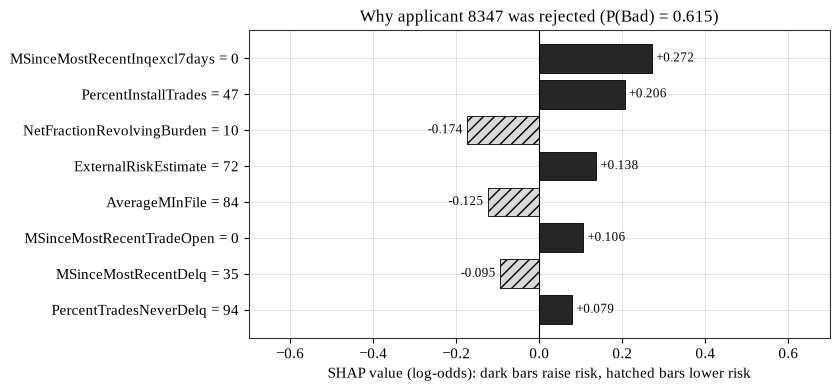

Base value + sum of SHAP values = 0.4681 | model log-odds = 0.4681


In [22]:
rejected_all = X_test.index[y_pred == 1]
rejected_bureau = [i for i in rejected_all if X_test_raw.loc[i, "ExternalRiskEstimate"] >= 0]
EXAMPLE_ID = rejected_bureau[1]     # the second rejected applicant with a bureau record; Step 16 shows the first has no feasible recourse,
                                    # so following the second lets us track one person through Steps 13 and 18
pos = X_test.index.get_loc(EXAMPLE_ID)
sv = pd.Series(shap_values[pos], index=FEATURES)
top = sv.reindex(sv.abs().sort_values(ascending=False).index).head(8)
fig, ax = plt.subplots(figsize=(7.5, 4))
cols = ["#262626" if v > 0 else "#d9d9d9" for v in top.values[::-1]]
hatch = ["" if v > 0 else "///" for v in top.values[::-1]]
bars = ax.barh([f"{f} = {X_test_raw.loc[EXAMPLE_ID, f]}" for f in top.index[::-1]], top.values[::-1], color=cols, edgecolor="black", linewidth=0.6)
for b, h in zip(bars, hatch): b.set_hatch(h)
ax.axvline(0, color="black", linewidth=0.8)
for b, v in zip(bars, top.values[::-1]):
    ax.text(v + (0.01 if v > 0 else -0.01), b.get_y() + b.get_height()/2, f"{v:+.3f}", va="center", ha="left" if v > 0 else "right", fontsize=9)
p_ex = float(model.predict_proba(X_test.loc[[EXAMPLE_ID]])[0, 1])
ax.set_xlabel("SHAP value (log-odds): dark bars raise risk, hatched bars lower risk")
ax.set_title(f"Why applicant {EXAMPLE_ID} was rejected (P(Bad) = {p_ex:.3f})")
ax.set_xlim(-0.7, 0.7)
plt.savefig("figures/fig_shap_local.png"); plt.show()
print("Base value + sum of SHAP values =", round(float(explainer.expected_value + sv.sum()), 4),
      "| model log-odds =", round(float(np.log(p_ex / (1 - p_ex))), 4))

## Step 14: Wrap WoE and the model into one pipeline that takes raw numbers

**Why:** a real customer (or the web app) gives raw numbers like "72" or the code "-7". So we build one object that (i) replaces codes with their WoE scores and then (ii) asks the model. The counterfactual search in Step 16 also works on these raw numbers. This has two big benefits:

* every suggested change is a **whole number** in real units (for example "3 credit cards with a balance", not "2.6"),
* features that hold a special code are **never** nudged into the WoE "pocket" mentioned in Step 4.

We check that this pipeline gives exactly the same predictions as the model on the test set.

In [23]:
class WoETransformer(BaseEstimator, TransformerMixin):
    # Replaces the special codes -7, -8, -9 with their WoE scores. Real values are untouched.
    def __init__(self, woe_map): self.woe_map = woe_map
    def fit(self, X, y=None): return self
    def transform(self, X): return apply_woe(pd.DataFrame(X, columns=FEATURES), self.woe_map)

pipe = Pipeline([("woe", WoETransformer(WOE_MAP)), ("xgb", model)])
diff = np.abs(pipe.predict_proba(X_test_raw)[:, 1] - y_proba).max()
print(f"Largest difference between pipeline and model on the test set: {diff:.10f}")

Largest difference between pipeline and model on the test set: 0.0000000000


## Step 15: Write down the actionability rules (what a person can and cannot change)

**Why:** a counterfactual like *"become 10 years younger"* or *"erase your past late payments"* is mathematically possible but useless in real life. The rules below turn the ideas in Sections 3.5.2 and 4.5.5 into code. The HELOC data has **no age column**, so the age rule in Section 3.5.2 has nothing to act on here; the delinquency rules do the same job.

The time horizon is **24 months**: we only suggest changes that could happen within two years.

| Rule | Meaning | Features |
|---|---|---|
| `fixed` | cannot be changed by the applicant | ExternalRiskEstimate (a bureau summary score that moves only as a result of the other behaviours), NumTrades60Ever2DerogPubRec, NumTrades90Ever2DerogPubRec, MaxDelqEver, MaxDelq2PublicRecLast12M, PercentTradesNeverDelq (past late payments cannot be erased), NumTotalTrades, PercentInstallTrades (the mix of accounts) |
| `up_time` | time can only move forward, up to +24 months | MSinceOldestTradeOpen, MSinceMostRecentTradeOpen, AverageMInFile, MSinceMostRecentDelq |
| `up_time_24` | as above, but this field stops at 24 in the data | MSinceMostRecentInqexcl7days |
| `up_to_total` | can rise as existing accounts are kept in good standing, but never above the total number of accounts | NumSatisfactoryTrades |
| `down` | can only go down, never below 0 (pay balances off, stop applying for credit) | NumTradesOpeninLast12M, NumInqLast6M, NumInqLast6Mexcl7days, NetFractionRevolvingBurden, NetFractionInstallBurden, NumRevolvingTradesWBalance, NumInstallTradesWBalance, NumBank2NatlTradesWHighUtilization, PercentTradesWBalance |

**Extra rule:** if a feature holds a special code (-7, -8 or -9) for this person, it is treated as `fixed`.

In [24]:
HORIZON = 24
RULES = {
    "ExternalRiskEstimate": "fixed", "MSinceOldestTradeOpen": "up_time", "MSinceMostRecentTradeOpen": "up_time",
    "AverageMInFile": "up_time", "NumSatisfactoryTrades": "up_to_total", "NumTrades60Ever2DerogPubRec": "fixed",
    "NumTrades90Ever2DerogPubRec": "fixed", "PercentTradesNeverDelq": "fixed", "MSinceMostRecentDelq": "up_time",
    "MaxDelq2PublicRecLast12M": "fixed", "MaxDelqEver": "fixed", "NumTotalTrades": "fixed",
    "NumTradesOpeninLast12M": "down", "PercentInstallTrades": "fixed", "MSinceMostRecentInqexcl7days": "up_time_24",
    "NumInqLast6M": "down", "NumInqLast6Mexcl7days": "down", "NetFractionRevolvingBurden": "down",
    "NetFractionInstallBurden": "down", "NumRevolvingTradesWBalance": "down", "NumInstallTradesWBalance": "down",
    "NumBank2NatlTradesWHighUtilization": "down", "PercentTradesWBalance": "down",
}

def action_bounds(row):
    # Per-applicant list of changeable features and the allowed [low, high] range for each.
    vary, ranges = [], {}
    for f, rule in RULES.items():
        v = row[f]
        if rule == "fixed" or v < 0: continue
        lo, hi = {"up_time": (v, v + HORIZON), "up_time_24": (v, min(v + HORIZON, 24)),
                  "up_to_total": (v, max(v, row["NumTotalTrades"])), "down": (0, v)}[rule]
        if hi > lo: vary.append(f); ranges[f] = [int(lo), int(hi)]
    return vary, ranges

def rule_violations(orig_raw, cf_model_space, cf_is_raw, return_notes=False):
    # Count broken rules in one counterfactual. cf_is_raw=False means the CF is in WoE (model) space.
    vary, ranges = action_bounds(orig_raw)
    orig_cmp = orig_raw.astype(float) if cf_is_raw else apply_woe(orig_raw.to_frame().T, WOE_MAP).iloc[0]
    out = {"fixed or coded feature changed": 0, "wrong direction or outside 24-month range": 0, "not a whole number": 0}
    notes = []
    for f in FEATURES:
        new, old = float(cf_model_space[f]), float(orig_cmp[f])
        if abs(new - old) < 1e-9: continue
        if f not in vary:
            out["fixed or coded feature changed"] += 1; notes.append(f"{f}: {orig_raw[f]} -> {new:.2f} (cannot be changed)"); continue
        lo, hi = ranges[f]
        if new < lo - 1e-9 or new > hi + 1e-9:
            out["wrong direction or outside 24-month range"] += 1; notes.append(f"{f}: {orig_raw[f]} -> {new:.2f} (allowed {lo} to {hi})")
        if abs(new - round(new)) > 1e-9:
            out["not a whole number"] += 1; notes.append(f"{f}: {new:.2f} (not a whole number)")
    return (out, notes) if return_notes else out

pd.DataFrame({"Rule": pd.Series(RULES)}).T

,ExternalRiskEstimate,MSinceOldestTradeOpen,MSinceMostRecentTradeOpen,AverageMInFile,NumSatisfactoryTrades,NumTrades60Ever2DerogPubRec,NumTrades90Ever2DerogPubRec,PercentTradesNeverDelq,MSinceMostRecentDelq,MaxDelq2PublicRecLast12M,...,PercentInstallTrades,MSinceMostRecentInqexcl7days,NumInqLast6M,NumInqLast6Mexcl7days,NetFractionRevolvingBurden,NetFractionInstallBurden,NumRevolvingTradesWBalance,NumInstallTradesWBalance,NumBank2NatlTradesWHighUtilization,PercentTradesWBalance
Rule,fixed,up_time,up_time,up_time,up_to_total,fixed,fixed,fixed,up_time,fixed,...,fixed,up_time_24,down,down,down,down,down,down,down,down


## Step 16: Constrained DiCE counterfactuals for 10 rejected applicants (3 each)

**The idea in simple words:** a counterfactual answers *"What is the smallest realistic change that would flip this person from rejected to approved?"* **DiCE** (Diverse Counterfactual Explanations) looks for several different answers at once, so a person can choose the path that suits them.

We use DiCE's **genetic** search, which works with any model (XGBoost is not smooth, so the gradient version cannot be used). It balances three goals, like the loss in Section 3.5.2:

i. **flip the decision** to approved (P(Bad) below 0.5),
ii. **stay close** to the person (proximity weight = 0.5),
iii. **give different options** from each other (diversity weight = 0.5).

**Who we explain:** the **first 10 rejected applicants in the test set who have a bureau record** (people with no bureau record have every feature coded, so nothing is changeable). This is a fixed rule, so nobody can say the examples were hand-picked.

**Feasibility check:** if DiCE finds nothing for a person, we ask a simple question: *"If this person made every allowed change in the most helpful direction all at once, would they be approved?"* If the answer is no, then no realistic fix exists within 24 months, and the empty result is the honest answer, not a search failure.

In [25]:
dice_bg = pd.concat([X_train_raw, y_train.rename("Target")], axis=1)    # real training people, raw units
dice_data = dice_ml.Data(dataframe=dice_bg, continuous_features=FEATURES, outcome_name="Target")
dice_model = dice_ml.Model(model=pipe, backend="sklearn")
dice_exp = Dice(dice_data, dice_model, method="genetic")

def generate_cfs(raw_row_df, seed=RANDOM_STATE, total=3):
    vary, ranges = action_bounds(raw_row_df.iloc[0])
    np.random.seed(seed); random.seed(seed)
    try:
        res = dice_exp.generate_counterfactuals(raw_row_df, total_CFs=total, desired_class=0,
                                                features_to_vary=vary, permitted_range=ranges,
                                                proximity_weight=0.5, diversity_weight=0.5, verbose=False)
        cfs = res.cf_examples_list[0].final_cfs_df
        return (None if cfs is None or len(cfs) == 0 else cfs[FEATURES].astype(float)), vary, ranges
    except Exception:
        return None, vary, ranges

def best_case_probability(raw_row, vary, ranges):
    best = raw_row.copy().astype(float)
    for f in vary: best[f] = ranges[f][0] if RULES[f] == "down" else ranges[f][1]
    return float(pipe.predict_proba(best.to_frame().T)[0, 1])

CF_IDS = rejected_bureau[:10]
cf_results, dice_times = {}, []
summary_rows = []
for i in CF_IDS:
    q = X_test_raw.loc[[i]]
    t = time.time(); cfs, vary, ranges = generate_cfs(q); dice_times.append(time.time() - t)
    cf_results[i] = cfs
    p0 = float(pipe.predict_proba(q)[0, 1])
    summary_rows.append({"Applicant": i, "P(Bad) now": p0, "Changeable features": len(vary),
                         "Best-case P(Bad)": best_case_probability(q.iloc[0], vary, ranges),
                         "Counterfactuals found": 0 if cfs is None else len(cfs),
                         "P(Bad) of each counterfactual": "" if cfs is None else ", ".join(f"{v:.3f}" for v in pipe.predict_proba(cfs)[:, 1])})
TIMINGS["Constrained DiCE (per rejected applicant, mean)"] = float(np.mean(dice_times))
cf_summary = pd.DataFrame(summary_rows).set_index("Applicant")
cf_summary.round(3)

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:12<00:00, 12.85s/it]

100%|██████████| 1/1 [00:12<00:00, 12.85s/it]

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  2.65it/s]

...

100%|██████████| 1/1 [00:00<00:00,  2.83it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  2.75it/s]

100%|██████████| 1/1 [00:00<00:00,  2.74it/s]

,P(Bad) now,Changeable features,Best-case P(Bad),Counterfactuals found,P(Bad) of each counterfactual
Applicant,,,,,
6470,0.794,11,0.746,0,
8347,0.615,12,0.357,3,"0.361, 0.399, 0.393"
3167,0.799,14,0.395,3,"0.480, 0.456, 0.482"
2642,0.661,8,0.473,2,"0.497, 0.495"
8573,0.681,13,0.570,0,
496,0.731,11,0.595,0,
4134,0.767,13,0.524,0,
5378,0.733,13,0.667,0,
8533,0.507,11,0.428,3,"0.496, 0.437, 0.492"


**What the result means:** for some applicants DiCE finds three options; for others it finds none. Look at the **Best-case P(Bad)** column: for every applicant with no counterfactual, even making *all* allowed changes at once leaves P(Bad) at or above 0.5. In other words, **under realistic rules, some rejected people cannot become approvable within 24 months.** This matches the warning in the recourse literature that unconstrained methods can hide this problem by suggesting impossible changes.

## Step 17: Measure the quality of the counterfactuals

**The measures in plain English (Section 3.6.2):**

* **Validity:** of the counterfactuals produced, the share that really flip the decision to approved when we feed them back to the model.
* **Coverage:** of the 10 applicants, the share who received at least one valid counterfactual.
* **Proximity (L1, raw units):** add up how far every feature moved. This is the dissertation's definition. Because features have different units (months, counts, percentages), we also give a **MAD-scaled L1**: each change is divided by that feature's typical spread (the median absolute deviation, MAD), so "1" means "one typical step".
* **Sparsity:** how many features had to change. Fewer is easier to act on.
* **Diversity:** how different the options for the same person are from each other (MAD-scaled L1 between pairs).
* **Rule compliance:** we check every counterfactual against every rule in Step 15 with code (not by eye).

In [26]:
MAD = {}
for f in FEATURES:
    vals = X_train_raw[f][X_train_raw[f] >= 0]
    mad = float(np.median(np.abs(vals - vals.median())))
    MAD[f] = mad if mad > 0 else 1.0

cf_rows = []
for i, cfs in cf_results.items():
    if cfs is None: continue
    orig = X_test_raw.loc[i].astype(float)
    for k in range(len(cfs)):
        c = cfs.iloc[k]; changed = [f for f in FEATURES if abs(c[f] - orig[f]) > 1e-9]
        viol = rule_violations(X_test_raw.loc[i], c, cf_is_raw=True)
        cf_rows.append({"Applicant": i, "CF": k + 1, "P(Bad)": float(pipe.predict_proba(c.to_frame().T)[0, 1]),
                        "Valid": float(pipe.predict_proba(c.to_frame().T)[0, 1]) < 0.5,
                        "L1 raw": float(sum(abs(c[f] - orig[f]) for f in FEATURES)),
                        "L1 MAD-scaled": float(sum(abs(c[f] - orig[f]) / MAD[f] for f in FEATURES)),
                        "Features changed": len(changed), "Changed": changed, "Rule violations": sum(viol.values())})
cf_df = pd.DataFrame(cf_rows)

div = []
for i, cfs in cf_results.items():
    if cfs is not None and len(cfs) > 1:
        for a in range(len(cfs)):
            for b in range(a + 1, len(cfs)):
                div.append(sum(abs(cfs.iloc[a][f] - cfs.iloc[b][f]) / MAD[f] for f in FEATURES))

exp_metrics = {
    "applicants_explained": len(CF_IDS), "cfs_requested": 3 * len(CF_IDS), "cfs_generated": int(len(cf_df)),
    "validity": float(cf_df["Valid"].mean()), "coverage": float(sum(c is not None for c in cf_results.values()) / len(CF_IDS)),
    "proximity": float(cf_df["L1 raw"].mean()), "proximity_mad": float(cf_df["L1 MAD-scaled"].mean()),
    "sparsity": float(cf_df["Features changed"].mean()), "diversity_mad": float(np.mean(div)) if div else None,
    "rule_compliance": float((cf_df["Rule violations"] == 0).mean()),
}
for k, v in exp_metrics.items(): print(f"{k:22s} {v if isinstance(v, int) else round(v, 4)}")
cf_df.drop(columns="Changed").round(3)

applicants_explained   10
cfs_requested          30
cfs_generated          14
validity               1.0
coverage               0.5
proximity              65.9286
proximity_mad          10.6029
sparsity               3.9286
diversity_mad          7.449
rule_compliance        1.0


,Applicant,CF,P(Bad),Valid,L1 raw,L1 MAD-scaled,Features changed,Rule violations
0,8347,1,0.361,True,26.0,15.250,6,0
1,8347,2,0.399,True,79.0,19.512,6,0
2,8347,3,0.393,True,85.0,20.729,6,0
3,3167,1,0.480,True,142.0,19.456,5,0
4,3167,2,0.456,True,74.0,14.001,6,0
5,3167,3,0.482,True,217.0,20.835,6,0
6,2642,1,0.497,True,37.0,1.907,2,0
7,2642,2,0.495,True,60.0,3.609,4,0
8,8533,1,0.496,True,13.0,0.812,1,0
9,8533,2,0.437,True,15.0,0.838,2,0


How many features each counterfactual changes:
Features changed
1    1
2    3
3    3
4    1
5    1
6    5


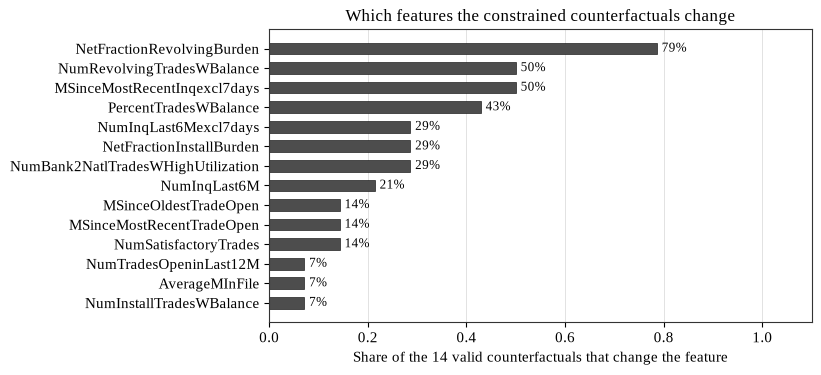

,Counterfactuals that change it,Share of all counterfactuals
NetFractionRevolvingBurden,11,0.786
NumRevolvingTradesWBalance,7,0.500
MSinceMostRecentInqexcl7days,7,0.500
PercentTradesWBalance,6,0.429
NumInqLast6Mexcl7days,4,0.286
NetFractionInstallBurden,4,0.286
NumBank2NatlTradesWHighUtilization,4,0.286
NumInqLast6M,3,0.214
MSinceOldestTradeOpen,2,0.143
MSinceMostRecentTradeOpen,2,0.143


In [27]:
freq = pd.Series([f for ch in cf_df["Changed"] for f in ch]).value_counts()
freq_tbl = pd.DataFrame({"Counterfactuals that change it": freq, "Share of all counterfactuals": (freq / len(cf_df)).round(3)})
spars_dist = cf_df["Features changed"].value_counts().sort_index()
print("How many features each counterfactual changes:"); print(spars_dist.to_string())
fig, ax = plt.subplots(figsize=(7, 3.8))
s = freq_tbl["Share of all counterfactuals"].iloc[::-1]
ax.barh(s.index, s.values, color="#4d4d4d", edgecolor="black", linewidth=0.4, height=0.6)
for j, v in enumerate(s.values): ax.text(v + 0.01, j, f"{v:.0%}", va="center", fontsize=9)
ax.set_xlim(0, 1.1); ax.set_xlabel(f"Share of the {len(cf_df)} valid counterfactuals that change the feature")
ax.set_title("Which features the constrained counterfactuals change"); ax.grid(axis="y", visible=False)
plt.savefig("figures/fig_cf_feature_frequency.png"); plt.show()
freq_tbl

## Step 18: One worked counterfactual example

**Why:** a table of averages hides what a person actually receives. Here are the three options for the applicant explained in Step 13, showing only the features that change.

In [28]:
cfs = cf_results[EXAMPLE_ID]
orig = X_test_raw.loc[EXAMPLE_ID]
changed_any = [f for f in FEATURES if any(abs(cfs.iloc[k][f] - orig[f]) > 1e-9 for k in range(len(cfs)))]
example_tbl = pd.DataFrame({"Now (rejected)": orig[changed_any].astype(int).astype(str)})
for k in range(len(cfs)): example_tbl[f"Option {k+1}"] = cfs.iloc[k][changed_any].astype(int).astype(str)
example_tbl.loc["P(Bad)"] = [f"{float(pipe.predict_proba(X_test_raw.loc[[EXAMPLE_ID]])[0, 1]):.3f}"] + \
                            [f"{p:.3f}" for p in pipe.predict_proba(cfs)[:, 1]]
example_tbl

,Now (rejected),Option 1,Option 2,Option 3
MSinceMostRecentTradeOpen,0,13,0,0
NumTradesOpeninLast12M,3,0,3,3
MSinceMostRecentInqexcl7days,0,4,9,9
NumInqLast6M,3,2,0,0
NumInqLast6Mexcl7days,3,0,1,0
NetFractionRevolvingBurden,10,10,5,0
NumRevolvingTradesWBalance,4,2,0,0
PercentTradesWBalance,56,56,0,0
P(Bad),0.615,0.361,0.399,0.393


**How to read it:** each column is one realistic plan. A loan officer could say, for example: *"If you pay your card balances down and avoid new credit applications for a while, our model would approve you."* No option touches the bureau score, past late payments or anything else the person cannot change.

## Step 19: What happens WITHOUT the rules? (the original appendix method)

**Why:** to prove the rules matter, we rerun the counterfactual search the way the first version of the code did it: DiCE **random** search, on the WoE (model) numbers, using the SMOTE-balanced training data, **every feature allowed to change**, for the **same 10 applicants**, 3 options each. This time we fix the random seed so the run can be repeated. Then we check every result against the same rules.

In [29]:
u_data = dice_ml.Data(dataframe=pd.concat([X_train_bal, y_train_bal.rename("Target")], axis=1),
                      continuous_features=FEATURES, outcome_name="Target")
u_exp = Dice(u_data, dice_ml.Model(model=model, backend="sklearn"), method="random")
u_rows = []
for i in CF_IDS:
    q = X_test.loc[[i]]
    try:
        res = u_exp.generate_counterfactuals(q, total_CFs=3, desired_class="opposite", random_seed=RANDOM_STATE, verbose=False)
        ucfs = res.cf_examples_list[0].final_cfs_df[FEATURES].astype(float)
    except Exception:
        ucfs = None
    if ucfs is None: continue
    for k in range(len(ucfs)):
        c = ucfs.iloc[k]; o = X_test.loc[i]
        viol, notes = rule_violations(X_test_raw.loc[i], c, cf_is_raw=False, return_notes=True)
        u_rows.append({"Applicant": i, "CF": k + 1, "Valid": model.predict(c.to_frame().T)[0] == 0,
                       "L1 raw": float(np.abs(c - o).sum()), "Features changed": int((np.abs(c - o) > 1e-9).sum()),
                       **viol, "Any violation": sum(viol.values()) > 0, "Notes": notes,
                       "Changed": [f for f in FEATURES if abs(c[f] - o[f]) > 1e-9]})
u_df = pd.DataFrame(u_rows)
compare_cf = pd.DataFrame({
    "Unconstrained (original method)": [len(u_df), u_df["Valid"].mean(), u_df["Applicant"].nunique()/10, u_df["L1 raw"].mean(),
                                        u_df["Features changed"].mean(), 1 - u_df["Any violation"].mean()],
    "Constrained (this framework)": [exp_metrics["cfs_generated"], exp_metrics["validity"], exp_metrics["coverage"],
                                     exp_metrics["proximity"], exp_metrics["sparsity"], exp_metrics["rule_compliance"]],
}, index=["Counterfactuals produced (of 30)", "Validity", "Coverage (of 10 applicants)", "Proximity (L1, raw units)",
          "Sparsity (features changed)", "Share obeying all rules"])
display(compare_cf.round(4))
print("Kinds of broken rules in the unconstrained run:")
print(u_df[["fixed or coded feature changed", "wrong direction or outside 24-month range", "not a whole number"]].sum().to_string())
print("\nExamples of impossible suggestions (first 12):")
shown = 0
for _, r in u_df.iterrows():
    for n in r["Notes"]:
        if shown < 12: print(f"  applicant {r['Applicant']} option {r['CF']}: {n}"); shown += 1

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  2.98it/s]

100%|██████████| 1/1 [00:00<00:00,  2.97it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  3.36it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  3.45it/s]

100%|██████████| 1/1 [00:00<00:00,  3.44it/s]

,Unconstrained (original method),Constrained (this framework)
Counterfactuals produced (of 30),30.0000,14.0000
Validity,1.0000,1.0000
Coverage (of 10 applicants),1.0000,0.5000
"Proximity (L1, raw units)",61.7917,65.9286
Sparsity (features changed),1.7333,3.9286
Share obeying all rules,0.0000,1.0000


Kinds of broken rules in the unconstrained run:
fixed or coded feature changed               25
wrong direction or outside 24-month range    15
not a whole number                           26

Examples of impossible suggestions (first 12):
  applicant 6470 option 1: ExternalRiskEstimate: 51 -> 78.06 (cannot be changed)
  applicant 6470 option 1: NumSatisfactoryTrades: 4 -> 65.60 (allowed 4 to 6)
  applicant 6470 option 1: NumSatisfactoryTrades: 65.60 (not a whole number)
  applicant 6470 option 2: ExternalRiskEstimate: 51 -> 91.16 (cannot be changed)
  applicant 6470 option 2: NumSatisfactoryTrades: 4 -> 76.62 (allowed 4 to 6)
  applicant 6470 option 2: NumSatisfactoryTrades: 76.62 (not a whole number)
  applicant 6470 option 2: NumRevolvingTradesWBalance: 1 -> 31.10 (allowed 0 to 1)
  applicant 6470 option 2: NumRevolvingTradesWBalance: 31.10 (not a whole number)
  applicant 6470 option 3: ExternalRiskEstimate: 51 -> 88.80 (cannot be changed)
  applicant 6470 option 3: NumSatisfactory

**What the result means:** without rules, DiCE looks better on paper: it finds options for **every** applicant and changes fewer features. But in this run **none of its 30 options obeys all the rules**: they raise the bureau score directly, move features the wrong way (for example erasing past late payments or making time run backwards), or suggest fractions such as part of an account. The constrained framework produces fewer options, but **every one of them obeys every rule**. This is the trade-off at the centre of the dissertation's research gap (Section 2.5): realistic recourse costs coverage and sparsity, and an honest system should show that cost.

## Step 20: Stability tests (Section 4.6.3 and research question iii)

**Why:** a trustworthy system should not change its mind, or its explanation, when the input moves by a tiny, meaningless amount (like a typing slip). We test three things:

i. **Prediction stability:** add small random noise to every real feature value of all 2,092 test people (special codes untouched, values never below 0), 10 times, and count how often the decision stays the same. We run it two ways:
    (a) the **literal** reading of Section 4.6.3: continuous noise, including noise of a fixed size of 0.01 units;
    (b) a **realistic** version: the noisy value is rounded back to a whole number, because every HELOC feature is a whole number (counts, months, percentages). The noise size is a fraction (0.01, 0.05, 0.10, 0.25) of each feature's spread (standard deviation, SD).
ii. **Counterfactual stability:** for each applicant who received counterfactuals, rerun DiCE (a) with 5 other random seeds and (b) on 5 realistic noisy copies of the person (0.10 SD, rounded). We compare the **set of features the advice asks to change**, using the Jaccard score (1 = exactly the same set, 0 = nothing in common).
iii. **SHAP versus LIME stability:** for 30 test people, we compare the top-5 features named by TreeSHAP and by LIME (a) when the method is simply run again and (b) on a realistic noisy copy (0.10 SD, rounded). LIME builds its explanation from random samples, so it can change between runs; TreeSHAP is exact.

In [30]:
def add_noise(raw_df, scale, rng, absolute=False, round_to_whole=False):
    noisy = raw_df.astype(float).copy()
    for f in FEATURES:
        real = raw_df[f] >= 0
        sd = 1.0 if absolute else float(X_train_raw[f][X_train_raw[f] >= 0].std())
        v = noisy.loc[real, f] + rng.normal(0, scale * sd, real.sum())
        noisy.loc[real, f] = (np.round(v) if round_to_whole else v).clip(lower=0)
    return noisy   # codes untouched; real values never drift below 0 into the special-code region

base_p = pipe.predict_proba(X_test_raw)[:, 1]; base_cls = (base_p >= 0.5).astype(int)
def stability_run(scale, absolute=False, round_to_whole=False, repeats=10):
    rng = np.random.RandomState(RANDOM_STATE); same, shift = [], []
    for _ in range(repeats):
        p = pipe.predict_proba(add_noise(X_test_raw, scale, rng, absolute, round_to_whole))[:, 1]
        same.append(np.mean((p >= 0.5).astype(int) == base_cls)); shift.append(np.mean(np.abs(p - base_p)) * 100)
    return np.mean(same), np.mean(shift)

rows = []
for label, scale, absolute, rnd in [("(a) continuous, sigma = 0.01 units", 0.01, True, False),
                                    ("(a) continuous, sigma = 0.01 SD", 0.01, False, False),
                                    ("(a) continuous, sigma = 0.05 SD", 0.05, False, False),
                                    ("(a) continuous, sigma = 0.10 SD", 0.10, False, False),
                                    ("(b) whole numbers, sigma = 0.01 SD", 0.01, False, True),
                                    ("(b) whole numbers, sigma = 0.05 SD", 0.05, False, True),
                                    ("(b) whole numbers, sigma = 0.10 SD", 0.10, False, True),
                                    ("(b) whole numbers, sigma = 0.25 SD", 0.25, False, True)]:
    same, shift = stability_run(scale, absolute, rnd)
    rows.append({"Noise": label, "Decisions unchanged": same, "Mean probability shift (points)": shift})
pred_stab = pd.DataFrame(rows).set_index("Noise")
pred_stab.round(4)

,Decisions unchanged,Mean probability shift (points)
Noise,,
"(a) continuous, sigma = 0.01 units",0.9435,4.3251
"(a) continuous, sigma = 0.01 SD",0.8989,7.2042
"(a) continuous, sigma = 0.05 SD",0.8496,10.8795
"(a) continuous, sigma = 0.10 SD",0.8380,11.5926
"(b) whole numbers, sigma = 0.01 SD",0.9988,0.0787
"(b) whole numbers, sigma = 0.05 SD",0.9820,1.2296
"(b) whole numbers, sigma = 0.10 SD",0.9620,2.5955
"(b) whole numbers, sigma = 0.25 SD",0.9248,5.2549


**Why do the two versions differ so much?** Look at where the trees split. SMOTE made 367 synthetic rows by drawing points *between* real people, so they hold decimals (for example 0.0024 inquiries). XGBoost then places some split points right next to real whole numbers, such as "is the number of inquiries below 0.0012?". A real person with 0 inquiries sits just under that line, so adding +0.01 pushes them across it, even though "0.01 of an inquiry" can never happen. The cell below counts these "knife-edge" split points. When the noise is rounded back to whole numbers, as real data would be, the decisions are far more stable.

In [31]:
trees = model.get_booster().trees_to_dataframe()
splits = trees[trees["Feature"] != "Leaf"]["Split"].astype(float)
frac = np.abs(splits - np.round(splits))
knife = ((frac > 0) & (frac < 0.05)).mean()
print(f"Split points in the 300 trees: {len(splits):,}")
print(f"Share lying within 0.05 of a whole number without being on it ('knife-edge'): {knife:.1%}")
print("Examples of knife-edge split points:", sorted(splits[(frac > 0) & (frac < 0.05)].round(4).unique())[:10])
splits_r = model_round.get_booster().trees_to_dataframe().query("Feature != 'Leaf'")["Split"].astype(float)
frac_r = np.abs(splits_r - np.round(splits_r))
print(f"Same share for the Check D model trained on rounded SMOTE rows: {((frac_r > 0) & (frac_r < 0.05)).mean():.1%}")
pipe_round = Pipeline([("woe", WoETransformer(WOE_MAP)), ("xgb", model_round)])
rng = np.random.RandomState(RANDOM_STATE); base_r = (pipe_round.predict_proba(X_test_raw)[:, 1] >= 0.5).astype(int); same_r = []
for _ in range(10):
    same_r.append(np.mean((pipe_round.predict_proba(add_noise(X_test_raw, 0.01, rng, absolute=True))[:, 1] >= 0.5).astype(int) == base_r))
literal_round = float(np.mean(same_r))
print(f"Literal test (continuous noise, 0.01 units): original model {pred_stab.iloc[0, 0]:.2%} unchanged | Check D model {literal_round:.2%} unchanged")

Split points in the 300 trees: 4,082
Share lying within 0.05 of a whole number without being on it ('knife-edge'): 16.3%
Examples of knife-edge split points: [-0.0173, -0.0164, -0.0026, 0.0012, 0.0069, 0.0077, 0.0157, 0.016, 0.0184, 0.0206]
Same share for the Check D model trained on rounded SMOTE rows: 0.0%


Literal test (continuous noise, 0.01 units): original model 94.35% unchanged | Check D model 100.00% unchanged


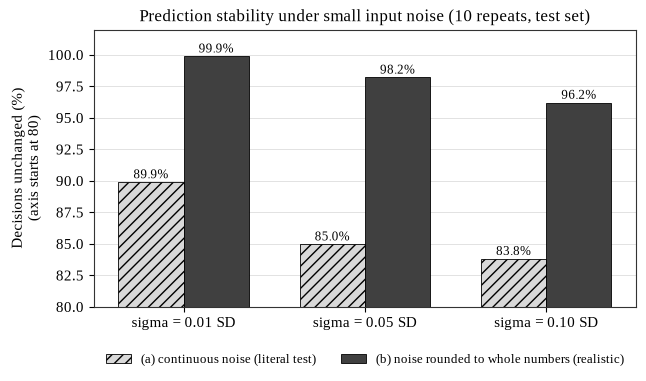

In [32]:
fig, ax = plt.subplots(figsize=(7, 3.6))
levels = ["0.01 SD", "0.05 SD", "0.10 SD"]
cont = [pred_stab.loc[f"(a) continuous, sigma = {l}", "Decisions unchanged"] * 100 for l in levels]
whole = [pred_stab.loc[f"(b) whole numbers, sigma = {l}", "Decisions unchanged"] * 100 for l in levels]
xpos = np.arange(len(levels)); w = 0.36
b1 = ax.bar(xpos - w/2, cont, w, color="#d9d9d9", edgecolor="black", linewidth=0.6, hatch="///", label="(a) continuous noise (literal test)")
b2 = ax.bar(xpos + w/2, whole, w, color="#404040", edgecolor="black", linewidth=0.6, label="(b) noise rounded to whole numbers (realistic)")
for bars in (b1, b2):
    for b in bars: ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3, f"{b.get_height():.1f}%", ha="center", fontsize=9)
ax.set_xticks(xpos); ax.set_xticklabels([f"sigma = {l}" for l in levels]); ax.set_ylim(80, 102)
ax.set_ylabel("Decisions unchanged (%)\n(axis starts at 80)"); ax.set_title("Prediction stability under small input noise (10 repeats, test set)")
ax.legend(frameon=False, fontsize=9, loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=2); ax.grid(axis="x", visible=False)
plt.savefig("figures/fig_prediction_stability.png"); plt.show()

In [33]:
def jaccard(a, b):
    a, b = set(a), set(b)
    return 1.0 if not a and not b else len(a & b) / len(a | b)

def changed_set(raw_row, cfs):
    if cfs is None: return None
    return {f for k in range(len(cfs)) for f in FEATURES if abs(cfs.iloc[k][f] - float(raw_row[f])) > 1e-9}

t = time.time()
seed_scores, noise_scores, seed_found, noise_found, noise_already_ok = [], [], [], [], 0
for i, cfs in cf_results.items():
    if cfs is None: continue
    ref = changed_set(X_test_raw.loc[i], cfs)
    for s in [1, 2, 3, 4, 5]:
        c2, _, _ = generate_cfs(X_test_raw.loc[[i]], seed=s)
        seed_found.append(c2 is not None)
        if c2 is not None: seed_scores.append(jaccard(ref, changed_set(X_test_raw.loc[i], c2)))
    rng = np.random.RandomState(RANDOM_STATE)
    for s in range(5):
        noisy = add_noise(X_test_raw.loc[[i]], 0.10, rng, round_to_whole=True).astype(int)
        if pipe.predict_proba(noisy)[0, 1] < 0.5:      # the nudged copy is already approved: no advice needed
            noise_already_ok += 1; continue
        c3, _, _ = generate_cfs(noisy, seed=RANDOM_STATE)
        noise_found.append(c3 is not None)
        if c3 is not None: noise_scores.append(jaccard(ref, changed_set(noisy.iloc[0], c3)))
TIMINGS["Counterfactual stability reruns"] = time.time() - t
cf_stab = {"cf_stability_seed": float(np.mean(seed_scores)), "cf_stability_noise": float(np.mean(noise_scores)),
           "cf_found_rate_seed_reruns": float(np.mean(seed_found)), "cf_found_rate_noisy_copies": float(np.mean(noise_found)),
           "noisy_copies_already_approved": int(noise_already_ok)}
for k, v in cf_stab.items(): print(f"{k:30s} {v if isinstance(v, int) else round(v, 4)}")

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  2.63it/s]

100%|██████████| 1/1 [00:00<00:00,  2.62it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  2.82it/s]

...

100%|██████████| 1/1 [00:00<00:00,  2.74it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  3.02it/s]

100%|██████████| 1/1 [00:00<00:00,  3.00it/s]

cf_stability_seed              0.718
cf_stability_noise             0.583
cf_found_rate_seed_reruns      1.0
cf_found_rate_noisy_copies     0.9583
noisy_copies_already_approved  1


In [34]:
lime_exp_cache = {}
def lime_top5(row_woe, seed):
    if seed not in lime_exp_cache:
        lime_exp_cache[seed] = lime_tabular.LimeTabularExplainer(X_train.values, feature_names=FEATURES,
                                   class_names=["Good", "Bad"], mode="classification", random_state=seed)
    e = lime_exp_cache[seed].explain_instance(row_woe.values, model.predict_proba, num_features=5, num_samples=5000)
    return [FEATURES[j] for j, _ in e.as_map()[1]]

def shap_top5(row_woe):
    v = explainer.shap_values(row_woe.to_frame().T)[0]
    return [FEATURES[j] for j in np.argsort(-np.abs(v))[:5]]

t = time.time(); rng = np.random.RandomState(RANDOM_STATE)
sl = {"SHAP rerun": [], "LIME rerun": [], "SHAP noise": [], "LIME noise": []}
for i in X_test.index[:30]:
    r = X_test.loc[i]
    r_noisy = apply_woe(add_noise(X_test_raw.loc[[i]], 0.10, rng, round_to_whole=True), WOE_MAP).iloc[0]
    s0, l0 = shap_top5(r), lime_top5(r, 1)
    sl["SHAP rerun"].append(jaccard(s0, shap_top5(r)));  sl["LIME rerun"].append(jaccard(l0, lime_top5(r, 2)))
    sl["SHAP noise"].append(jaccard(s0, shap_top5(r_noisy))); sl["LIME noise"].append(jaccard(l0, lime_top5(r_noisy, 1)))
TIMINGS["SHAP vs LIME stability (30 applicants)"] = time.time() - t
sl_df = pd.DataFrame({"Run again (same input)": [np.mean(sl["SHAP rerun"]), np.mean(sl["LIME rerun"])],
                      "Realistic noisy copy (0.10 SD, whole numbers)": [np.mean(sl["SHAP noise"]), np.mean(sl["LIME noise"])]},
                     index=["TreeSHAP top-5", "LIME top-5"])
sl_df.round(4)

,Run again (same input),"Realistic noisy copy (0.10 SD, whole numbers)"
TreeSHAP top-5,1.0000,0.8175
LIME top-5,0.8667,0.8063


**What the results mean:**

* **Predictions:** under the literal continuous test, a noticeable share of decisions flip even with noise of only 0.01 units, because of the knife-edge split points created by SMOTE's decimal rows. Under the realistic whole-number test, decisions are very stable at small noise and fall slowly as the noise grows. This is a real lesson about the design, not only a number. Check D in Step 11 trained the same model on SMOTE rows rounded to whole numbers: the knife-edge split points disappear (0.0% instead of 16.3%), the literal test keeps 100% of decisions unchanged, and the test AUC moves only from 0.7933 to 0.7924.
* **Counterfactuals:** the Jaccard scores show how often the advice names the same features when the search is repeated or the person is nudged. A score below 1 means the genetic search can find a different, equally valid plan: plans are not unique.
* **SHAP versus LIME:** TreeSHAP gives the same top-5 every time for the same input (score 1.0), because it is exact. LIME names somewhat different features when simply run again, because it relies on random samples. This answers research question iii with measured evidence rather than assertion.

## Step 21: How long each stage takes

**Why:** Section 4.6.2 discusses whether the framework is fast enough for real use. These times come from this run on the machine shown below (they will differ on other hardware).

In [35]:
import platform, multiprocessing
print("Machine:", platform.processor() or platform.machine(), "|", multiprocessing.cpu_count(), "CPU cores |", platform.platform())
time_df = pd.DataFrame({"Seconds": pd.Series(TIMINGS)}).round(2)
time_df

Machine: x86_64 | 2 CPU cores | Linux-6.18.44-fc-v70-x86_64-with-glibc2.39


,Seconds
Preprocessing (WoE + split + SMOTE),0.14
Hyperparameter optimisation (20 trials x 3 folds),70.36
Final XGBoost training,1.62
"TreeSHAP values for the test set (n = 2,092)",0.63
TreeSHAP interaction values (500 applicants),7.07
"Constrained DiCE (per rejected applicant, mean)",8.15
Counterfactual stability reruns,227.59
SHAP vs LIME stability (30 applicants),31.18


## Step 22: Save everything the web app needs

**Why:** the Streamlit app (`app.py`) must use **exactly** the same model, the same WoE scores and the same rules as this notebook, otherwise the app and the thesis would disagree. We save:

| File | What it holds |
|---|---|
| `model.pkl` | the trained XGBoost model |
| `woe_map.json` | the WoE score for every special code |
| `actionability_rules.json` | the rules from Step 15 and the 24-month horizon |
| `dice_background.csv` | the real training applicants (raw units), which DiCE uses to learn realistic ranges |
| `metrics.json` | the test-set scores from Step 9 |
| `exp_metrics.json` | the counterfactual and stability scores from Steps 17 and 20 |
| `figures/*.png` | every chart in this notebook |

In [36]:
with open("woe_map.json", "w") as f: json.dump({c: {str(k): v for k, v in d.items()} for c, d in WOE_MAP.items()}, f, indent=2)
with open("actionability_rules.json", "w") as f: json.dump({"horizon_months": HORIZON, "rules": RULES}, f, indent=2)
dice_bg.to_csv("dice_background.csv", index=False)
exp_metrics.update(cf_stab)
exp_metrics.update({"literal_stability_rounded_smote_model": literal_round})
exp_metrics.update({"prediction_stability_literal_0.01units": float(pred_stab.loc["(a) continuous, sigma = 0.01 units", "Decisions unchanged"]),
                    "prediction_stability_whole_0.10sd": float(pred_stab.loc["(b) whole numbers, sigma = 0.10 SD", "Decisions unchanged"]),
                    "shap_top5_rerun_jaccard": float(sl_df.loc["TreeSHAP top-5", "Run again (same input)"]),
                    "lime_top5_rerun_jaccard": float(sl_df.loc["LIME top-5", "Run again (same input)"])})
with open("exp_metrics.json", "w") as f: json.dump(exp_metrics, f, indent=2)
print("Saved:", ", ".join(["model.pkl", "woe_map.json", "actionability_rules.json", "dice_background.csv", "metrics.json", "exp_metrics.json"]))
print("Figures:", sorted(os.listdir("figures")))

Saved: model.pkl, woe_map.json, actionability_rules.json, dice_background.csv, metrics.json, exp_metrics.json
Figures: ['fig_baselines.png', 'fig_cf_feature_frequency.png', 'fig_class_distribution.png', 'fig_confusion.png', 'fig_optuna_history.png', 'fig_prediction_stability.png', 'fig_roc.png', 'fig_shap_beeswarm.png', 'fig_shap_dependence.png', 'fig_shap_importance.png', 'fig_shap_local.png']


## Step 23: Final results table (the numbers Chapter 4 and Chapter 5 should report)

Every number below comes from the cells above. If any number in the dissertation differs from this table, the table is the one backed by code.

In [37]:
final = pd.DataFrame([
    ("Data", "Applicants / features", f"{len(df):,} / {len(FEATURES)}"),
    ("Data", "Bad / Good (whole file)", f"{int(y_all.sum()):,} ({y_all.mean():.2%}) / {int((1-y_all).sum()):,} ({1-y_all.mean():.2%})"),
    ("Data", "Training before / after SMOTE", f"{len(X_train):,} / {len(X_train_bal):,} (4,367 per class)"),
    ("Data", "Test set (Good / Bad)", f"{len(X_test):,} ({int((y_test==0).sum()):,} / {int(y_test.sum()):,})"),
    ("Tuning", "Best trial / mean CV AUC", f"trial {study.best_trial.number} / {study.best_value:.4f}"),
    ("Tuning", "Best settings", ", ".join(f"{k} = {round(v, 4) if isinstance(v, float) else v}" for k, v in study.best_params.items())),
    ("Prediction", "AUC-ROC (95% bootstrap interval)", f"{metrics['auc']:.4f} ({metrics['auc_ci_low']:.4f} to {metrics['auc_ci_high']:.4f})"),
    ("Prediction", "Gini / KS", f"{metrics['gini']:.4f} / {metrics['ks']:.4f}"),
    ("Prediction", "Accuracy / Precision / Recall / F1", f"{metrics['acc']:.4f} / {metrics['prec']:.4f} / {metrics['rec']:.4f} / {metrics['f1']:.4f}"),
    ("Prediction", "Confusion matrix (TN, FP, FN, TP)", f"{tn}, {fp}, {fn}, {tp}"),
    ("Baselines", "AUC: LR / RF / XGB default", " / ".join(f"{base_df.loc[n, 'AUC-ROC']:.4f}" for n in base_df.index)),
    ("Baselines", "DeLong p-value vs LR / RF / XGB default", " / ".join(f"{delong_df['p-value'].iloc[j]:.4f}" for j in range(3))),
    ("SHAP", "Top five (mean |SHAP|)", "; ".join(f"{f} {v:.4f}" for f, v in shap_imp.head(5).items())),
    ("DiCE", "Applicants / CFs produced of requested", f"{exp_metrics['applicants_explained']} / {exp_metrics['cfs_generated']} of {exp_metrics['cfs_requested']}"),
    ("DiCE", "Validity / coverage / rule compliance", f"{exp_metrics['validity']:.4f} / {exp_metrics['coverage']:.4f} / {exp_metrics['rule_compliance']:.4f}"),
    ("DiCE", "Proximity L1 raw / MAD-scaled", f"{exp_metrics['proximity']:.2f} / {exp_metrics['proximity_mad']:.2f}"),
    ("DiCE", "Sparsity / diversity (MAD-scaled)", f"{exp_metrics['sparsity']:.2f} / {exp_metrics['diversity_mad']:.2f}"),
    ("Stability", "Decisions unchanged: literal 0.01 units / realistic 0.10 SD", f"{exp_metrics['prediction_stability_literal_0.01units']:.4f} / {exp_metrics['prediction_stability_whole_0.10sd']:.4f}"),
    ("Stability", "CF Jaccard: other seeds / noisy copies", f"{cf_stab['cf_stability_seed']:.4f} / {cf_stab['cf_stability_noise']:.4f}"),
    ("Stability", "Top-5 Jaccard on rerun: SHAP / LIME", f"{sl_df.iloc[0, 0]:.4f} / {sl_df.iloc[1, 0]:.4f}"),
], columns=["Area", "Measure", "Value"]).set_index(["Area", "Measure"])
pd.set_option("display.max_colwidth", 200)
final

Value
Area       Measure                                                                                                                                                                                                               
Data       Applicants / features                                                                                                                                                                                      10,459 / 23
           Bad / Good (whole file)                                                                                                                                                                5,459 (52.19%) / 5,000 (47.81%)
           Training before / after SMOTE                                                                                                                                                          8,367 / 8,734 (4,367 per class)
           Test set (Good / Bad)                                                                                                                                                                            2,092 (1,000 / 1,092)
Tuning     Best trial / mean CV AUC                                                                                                                                                                              trial 3 / 0.8066
           Best settings                                                                                                 max_depth = 4, learning_rate = 0.0281, n_estimators = 300, subsample = 0.7728, colsample_bytree = 0.7165
Prediction AUC-ROC (95% bootstrap interval)                                                                                                                                                             0.7933 (0.7742 to 0.8125)
           Gini / KS                                                                                                                                                                                              0.5865 / 0.4433
           Accuracy / Precision / Recall / F1                                                                                                                                                   0.7213 / 0.7192 / 0.7647 / 0.7412
           Confusion matrix (TN, FP, FN, TP)                                                                                                                                                                   674, 326, 257, 835
Baselines  AUC: LR / RF / XGB default                                                                                                                                                                    0.7669 / 0.7898 / 0.7719
           DeLong p-value vs LR / RF / XGB default                                                                                                                                                       0.0000 / 0.3015 / 0.0000
SHAP       Top five (mean |SHAP|)                                       ExternalRiskEstimate 0.5381; MSinceMostRecentInqexcl7days 0.3267; NetFractionRevolvingBurden 0.2462; AverageMInFile 0.1955; PercentTradesNeverDelq 0.1561
DiCE       Applicants / CFs produced of requested                                                                                                                                                                   10 / 14 of 30
           Validity / coverage / rule compliance                                                                                                                                                         1.0000 / 0.5000 / 1.0000
           Proximity L1 raw / MAD-scaled                                                                                                                                                                            65.93 / 10.60
           Sparsity / diversity (MAD-scaled)                                                                                                            